# Credit Card Transactions — PySpark Ingestion, Cleaning & Analysis

**Data engineering assessment.** This notebook reads a messy, nested JSON feed of credit-card
transactions with PySpark, flattens it to the required tabular schema, cleans it, protects the
personal data in it, and then looks for something worth knowing.

The four things the brief asks to be explained explicitly are answered in their own sections:

| Requirement | Section |
|---|---|
| **JSON flattening** to the 26 expected columns | §2 |
| **Data quality** — how dirty data is found and handled | §4 |
| **Timestamp conversion** to UTC+8, `YYYY-MM-DD HH:MM:SS.SSSSSS Z` | §4.1 |
| **Name derivation** from `person_name` | §4.2 |
| **PII handling** | §5 |
| **Visualisation & insight** | §7 |

### The data

The input is the assessment's own extract — 1.3 million transactions, 967 MB of newline-delimited
JSON. It is **not** committed: `data/` is gitignored in full, because a feed carrying card numbers,
names and street addresses does not belong in a repository. See the README for where to put it.

Three properties of this file shape most of what follows, and none of them is visible from the
column list:

1. **The nesting is doubly encoded.** `personal_detail` is not a nested object, it is a *string*
   containing JSON — and `address` inside it is a second escaped JSON string inside that. A struct
   flattener alone recovers nothing (§2).
2. **The three time columns use three different units.** `trans_date_trans_time` is a naive
   datetime string with no offset; `merch_eff_time` is epoch **microseconds**; `merch_last_update_time`
   is epoch **milliseconds**. Roughly a tenth of both merchant columns is digit-truncated and is not
   a valid instant in any unit (§4.1).
3. **`person_name` uses four different separators** — `,`, `@`, `|`, `/` — with padding junk
   (`eeeee`, `NOOOO`, `!!!`, `!`) attached in most encodings (§4.2).

### The stance this notebook takes

Three decisions shape everything below, so they are worth stating up front.

**Nothing is silently dropped.** Every record that fails a rule is *tagged* with the rule it
failed and routed to a quarantine table, not deleted. A pipeline that quietly discards 4% of its
input is a pipeline that will one day quietly discard 40% of it. The quarantine table is a
first-class output — and it gets the same PII treatment as the clean rows (§5.3a), because a row
that broke a rule is still somebody's transaction.

**Types are never inferred.** The file is read with every leaf forced to `string`, and each column
is then cast deliberately with an explicit failure path. Letting Spark infer types on dirty data
means Spark decides what to null out, and it does so without telling you. The same rule applies to
the embedded JSON in §2 and to the epoch units in §4.1: the *shape* is inferred, the *values* are
never guessed at.

**PII is handled in layers, not in one pass.** The raw layer keeps everything, the curated layer
replaces identifiers with keyed tokens, and the analytics layer generalises the quasi-identifiers
that make re-identification possible. Only the last one is meant to be widely readable.


---
## 0. Environment

Spark runs in local mode inside the container. Two configuration choices matter for correctness
rather than performance:

`spark.sql.session.timeZone = UTC` — the source encodes time in at least five different ways, some
of which are naive strings with no offset. Pinning the session to UTC means a naive string is
interpreted as UTC rather than as "whatever the container's clock happens to be set to", which
would make the output depend on where the notebook is run. The UTC+8 conversion the brief asks for
then happens explicitly, once, at the end of the parsing chain.

`spark.sql.ansi.enabled = false` (the default) — a failed `cast` yields `NULL` rather than throwing.
That is what makes "cast, then check what became null" a usable validation strategy.

`spark.sql.legacy.timeParserPolicy = CORRECTED` — this one is not optional, and it is easy to get
wrong. Under Spark 3's **default** `EXCEPTION` policy, `to_timestamp("1994-05-04 00:00:00",
"yyyy-MM-dd")` does not return `NULL`; it **throws** and kills the job, because the string partially
matches and Spark refuses to guess. That makes the "try several formats and `coalesce`" strategy in
§4.1 impossible — the first non-matching candidate aborts the query. `CORRECTED` restores
`NULL`-on-failure with the ISO-8601-correct parser, which is what the coalesce chain needs.
(`LEGACY` would also return `NULL`, but it brings back the lenient pre-3.0 parser, which happily
accepts genuinely malformed dates — the opposite of what a cleaning pipeline wants.)


In [1]:
import os
import json
import hashlib
import hmac as hmac_lib
from datetime import datetime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession, Window
from pyspark.sql import functions as F
from pyspark.sql import types as T

# Installed as an editable package from pyproject.toml, so this is a normal
# import rather than a sys.path fixup.
from paynet_iv import viz_theme as vz

vz.apply_theme()
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

spark = (
    SparkSession.builder
    .appName("paynet-iv-credit-card-transactions")
    .master("local[*]")
    # 1.3M rows / 967 MB, and local mode means the driver is also the executor.
    .config("spark.driver.memory", "5g")
    .config("spark.sql.session.timeZone", "UTC")
    .config("spark.sql.shuffle.partitions", "32")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .config("spark.sql.legacy.timeParserPolicy", "CORRECTED")
    # Progress bars are written to stderr and interleave into every cell's
    # output, which makes the notebook unreadable once it is committed.
    .config("spark.ui.showConsoleProgress", "false")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

# The dq_flags expression in §4.7 is ~50 CASE WHENs wide, which pushes Spark's
# whole-stage codegen past the JVM's hard 64 KB method limit. Spark handles this
# correctly by falling back to the interpreted path -- but it logs a full stack
# trace while doing so, which buries the actual cell output. Silence that one
# logger rather than the whole category.
try:
    _jvm = spark.sparkContext._jvm
    _jvm.org.apache.logging.log4j.core.config.Configurator.setLevel(
        "org.apache.spark.sql.catalyst.expressions.codegen.CodeGenerator",
        _jvm.org.apache.logging.log4j.Level.FATAL,
    )
except Exception as exc:                      # different log backend -- not fatal
    print(f"(could not adjust codegen logger: {exc})")

# --- display-time redaction -------------------------------------------
# §5 protects the data at rest. That happens late, and the profiling previews in
# §1-§4 run BEFORE it, on values that are still raw. On the synthetic file that
# is harmless; on the Kaggle file it would commit real card numbers, addresses
# and dates of birth into a notebook that then goes to GitHub.
#
# So previews are redacted by CHARACTER CLASS rather than blanked: digits become
# 9, upper becomes X, lower becomes x, and punctuation and spacing are kept
# verbatim. That destroys the identity while preserving the thing the profiling
# cells exist to show — the SHAPE of the defect. "4532-0124-0568-2992" reads as
# "9999-9999-9999-9999", and "Dr. EDWARD,, Sanchez" as "Xx. XXXXXX,, Xxxxxxx",
# which is still visibly a honorific, a doubled separator and a casing problem.
PII_PREVIEW_COLUMNS = {
    "cc_num", "person_name", "first", "last", "street", "dob", "trans_num", "job",
}

def _redact_value(v):
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return v
    out = []
    for ch in str(v):
        out.append("9" if ch.isdigit() else "X" if ch.isupper() else "x" if ch.islower() else ch)
    return "".join(out)

def _preview_base_name(c):
    """Reduce a frame's column name to the identity it actually holds.

    A preview column may arrive as a flattened path ("cardholder.cc_num") or as
    a carried-along original ("person_name__raw"); both hold the same value as
    the bare column and both have to redact. Matching on the raw label instead
    is how a previous version of this notebook leaked -- it aliased the column
    to "value" first, the lookup missed, and the card numbers printed in full.
    """
    base = str(c).split(".")[-1].lower()
    return base[: -len("__raw")] if base.endswith("__raw") else base


def redact(pdf, columns=PII_PREVIEW_COLUMNS):
    """Redact PII columns of a pandas frame for display. Never used on stored data."""
    out = pdf.copy()
    for c in out.columns:
        if _preview_base_name(c) in columns:
            out[c] = out[c].map(_redact_value)
    return out

def redact_line(s):
    """Redact a whole raw line by character class — for previews of text that
    was never parsed into columns, so there is nothing to redact selectively."""
    return _redact_value(s)


RAW_PATH = "../data/raw/transactions.json"
CURATED_DIR = "../data/curated"

print(f"Spark {spark.version} | session tz = {spark.conf.get('spark.sql.session.timeZone')}")
print(f"input : {RAW_PATH}")

# --- the UTC+8 rendering offset ---------------------------------------
# The brief asks for timestamps rendered at UTC+8. "Asia/Singapore" is used as
# the MECHANISM for that shift because it has observed no daylight saving since
# 1982, so it is a constant +08:00 — it is NOT a claim about where a cardholder
# lives. The records carry US addresses; see §4.1 and §7.1, where every hour is
# labelled "UTC+8 hour" rather than "local time" for exactly that reason.
DISPLAY_TZ = "Asia/Singapore"
TS_FORMAT = "yyyy-MM-dd HH:mm:ss.SSSSSS"


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/23 01:16:44 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark 3.5.3 | session tz = UTC
input : ../data/raw/transactions.json


---
## 1. Ingestion

### 1.1 Read everything as text first

The instinct is `spark.read.json(path)` and move on. That is a mistake on a feed like this one.
Schema inference scans the data, picks a type per field, and then *applies* it — so `"$1,204.50"`
in a column Spark decided was `double` becomes `NULL` before any code of mine runs. The corruption
is invisible: the column looks clean, it is just missing values.

So the read happens in two passes:

1. **Infer the structure** — purely to learn the nesting, not the types.
2. **Rewrite that structure with every leaf as `string`** and re-read with it supplied explicitly.

This keeps the shape (which can be arbitrarily nested and is not known in advance) while giving up
none of the control over types. Every value arrives exactly as it was written, and every
subsequent `NULL` is one this notebook created on purpose.

`mode=PERMISSIVE` with a `_corrupt_record` column catches lines that are not valid JSON at all —
those cannot be parsed into *any* schema and would otherwise abort the read.


In [2]:
# Pass 1 — learn the structure only.
inferred_schema = (
    spark.read
    .option("mode", "PERMISSIVE")
    .option("columnNameOfCorruptRecord", "_corrupt_record")
    .json(RAW_PATH)
    .schema
)

print("Inferred structure (types here are discarded — only the shape is kept):")
print(inferred_schema.simpleString()[:1200], "...")


Inferred structure (types here are discarded — only the shape is kept):
struct<Unnamed: 0:string,amt:string,category:string,cc_bic:string,cc_num:string,is_fraud:string,merch_eff_time:string,merch_last_update_time:string,merch_lat:string,merch_long:string,merch_zipcode:string,merchant:string,personal_detail:string,trans_date_trans_time:string,trans_num:string> ...


In [3]:
def stringify_schema(dtype):
    # Walk the inferred schema and replace every leaf type with StringType,
    # leaving the struct/array/map skeleton intact. Recursion handles nesting
    # of any depth, so this does not need to know the feed's layout.
    if isinstance(dtype, T.StructType):
        return T.StructType([
            T.StructField(f.name, stringify_schema(f.dataType), nullable=True)
            for f in dtype.fields
        ])
    if isinstance(dtype, T.ArrayType):
        return T.ArrayType(stringify_schema(dtype.elementType), containsNull=True)
    if isinstance(dtype, T.MapType):
        return T.MapType(T.StringType(), stringify_schema(dtype.valueType), True)
    return T.StringType()


string_schema = stringify_schema(inferred_schema)

# PERMISSIVE mode only populates _corrupt_record if the column is declared.
if "_corrupt_record" not in string_schema.fieldNames():
    string_schema = string_schema.add(T.StructField("_corrupt_record", T.StringType(), True))

# Pass 2 — the real read.
raw_df = (
    spark.read
    .option("mode", "PERMISSIVE")
    .option("columnNameOfCorruptRecord", "_corrupt_record")
    .schema(string_schema)
    .json(RAW_PATH)
)

# Spark refuses to filter a JSON source on _corrupt_record alone unless the
# frame is materialised first — this cache is load-bearing, not an optimisation.
raw_df = raw_df.cache()

total_lines = raw_df.count()
corrupt_df = raw_df.filter(F.col("_corrupt_record").isNotNull())
n_corrupt = corrupt_df.count()

print(f"lines read      : {total_lines:,}")
print(f"unparseable JSON: {n_corrupt:,}  ({n_corrupt / total_lines:.3%})")
if n_corrupt:
    # An unparseable line is the ONE preview that cannot be redacted by column,
    # because it never became columns — the parse is what failed. So the whole
    # line goes through the same character-class redaction: the structural
    # defect (the missing value after "cc_num":) stays legible, the card number
    # on a real feed's malformed line does not.
    print("\nexamples (redacted by character class — structure kept, values not):")
    for r in corrupt_df.select("_corrupt_record").limit(3).collect():
        print("   ", redact_line(r[0][:110]))


lines read      : 1,296,675
unparseable JSON: 0  (0.000%)


In [4]:
# The structurally broken lines are the first quarantine bucket. They are kept,
# not discarded — an operator needs to see them to fix the upstream producer.
#
# MATERIALISED HERE, not referenced lazily. Spark refuses to serve a query whose
# only referenced column from a JSON source is `_corrupt_record` -- it cannot
# distinguish "this line failed to parse" from "you projected nothing else" --
# which is why raw_df is cached above. §4.7 then releases that cache to reclaim
# memory for a 1.3M-row pipeline, and a lazy quarantine_corrupt would hit the
# restriction again when §8 finally writes it. Collecting now, while the cache
# is warm, produces a frame that no longer depends on the JSON relation at all.
#
# Collecting to the driver is safe because this bucket is bounded by definition:
# a feed where it is not bounded has a producer problem that a quarantine table
# is not the right response to. The cap makes that assumption explicit.
MAX_CORRUPT_COLLECT = 100_000

_corrupt_lines = [
    r[0] for r in
    corrupt_df.select("_corrupt_record").limit(MAX_CORRUPT_COLLECT).collect()
]
if n_corrupt > MAX_CORRUPT_COLLECT:
    print(f"WARNING: {n_corrupt:,} unparseable lines exceed the {MAX_CORRUPT_COLLECT:,} cap; "
          "the quarantine holds the first batch only. Investigate the producer.")

# Stored REDACTED by character class, for the same reason the previews are (§0):
# a line that failed to parse cannot be protected column by column, because it
# never became columns -- so if it happens to hold a card number, a raw copy in
# `data/curated/` would be the least protected identifier in the pipeline
# sitting in the most readable place. The redaction preserves what the bucket is
# for: the shape of the malformation, and where in the line it starts. The
# byte-exact original stays in the source file, which is the restricted bronze
# artefact and is where a replay would read it from anyway.
QUARANTINE_CORRUPT_SCHEMA = T.StructType([
    T.StructField("raw_line_redacted", T.StringType(), True),
    T.StructField("raw_line_chars", T.IntegerType(), True),
    T.StructField("reject_reason", T.StringType(), True),
])
quarantine_corrupt = spark.createDataFrame(
    [(_redact_value(line), len(line), "PARSE_FAILURE") for line in _corrupt_lines],
    schema=QUARANTINE_CORRUPT_SCHEMA,
)

parsed_df = raw_df.filter(F.col("_corrupt_record").isNull()).drop("_corrupt_record")
print(f"unparseable lines materialised: {quarantine_corrupt.count():,}")
print(f"rows carried forward: {parsed_df.count():,}")


unparseable lines materialised: 0


rows carried forward: 1,296,675


---
## 2. JSON flattening

The brief wants a flat table of 26 named columns. Getting there needs **two** different expansions,
because this feed nests in two different ways.

**Structs.** `personal_detail` holds the cardholder, with the address nested again below that.
Rather than hand-write `col("personal_detail.address.zip").alias("zip")` twenty times, §2.1 uses a
**generic flattener**: it repeatedly expands any struct-typed column into its children until no
structs remain. This costs nothing extra to write and is robust to the producer moving a field
between nesting levels — a very common source of breakage in JSON feeds.

**JSON inside a string.** The harder case, and the one the real feed actually uses:
`personal_detail` is not a JSON *object*, it is a JSON *string* whose content is an object —
and `address` inside it is a second escaped JSON string inside that. The struct flattener cannot
see either of them, because to Spark they are just text:

```
"personal_detail": "{\"person_name\":\"Jennifer,Banks,eeeee\", ...,
                     \"address\":\"{\\\"street\\\":\\\"561 Perry Cove\\\", ...}\"}"
```

So §2.1 alternates the two: expand the structs, look for string columns whose values parse as JSON
objects, `from_json` them into structs, expand again, and repeat until a pass changes nothing. The
embedded schema is **inferred from a sample and then stringified**, exactly like the top-level read
in §1 — the shape is learned, the types are discarded, and every leaf arrives as text.

This is worth doing generically rather than hard-coding `personal_detail`. Double-encoded JSON is
what you get when a producer serialises a sub-object before serialising the record, and the layer
that does it is rarely the layer you are told about. A flattener that handles it by construction
does not care how many levels there turn out to be, or which column they are hiding in.

A required column that is **absent**, or whose leaf name resolves to **two** different source
columns, stops the run rather than being papered over with a NULL — a silently null column is the
same class of failure as an inferred type.

§2.2 then maps the flattened names onto the required output names by **leaf name**, so
`personal_detail.address.zip` resolves to `zip` regardless of the path it arrived on.


In [5]:
def flatten_structs(df, sep="."):
    # Iteratively expand struct columns. Each pass promotes one level of
    # nesting; the loop ends when the schema is flat.
    while True:
        struct_fields = [
            f.name for f in df.schema.fields if isinstance(f.dataType, T.StructType)
        ]
        if not struct_fields:
            return df

        projection = []
        for f in df.schema.fields:
            if f.name in struct_fields:
                for child in f.dataType.fields:
                    projection.append(
                        F.col(f"`{f.name}`.`{child.name}`").alias(f"{f.name}{sep}{child.name}")
                    )
            else:
                projection.append(F.col(f"`{f.name}`"))
        df = df.select(projection)


JSON_OBJECT = r"^\s*\{"          # a string whose content is a JSON object


def embedded_json_columns(df, probe_rows=200):
    """String columns whose values look like a serialised JSON object.

    Probed rather than hard-coded: `limit(probe_rows)` after the filter means
    Spark stops reading as soon as it has found some, so this is cheap even
    though the frame is a million rows.
    """
    found = []
    for f in df.schema.fields:
        if not isinstance(f.dataType, T.StringType) or f.name == "_corrupt_record":
            continue
        hit = (
            df.select(F.col(f"`{f.name}`").alias("v"))
              .filter(F.col("v").isNotNull() & F.col("v").rlike(JSON_OBJECT))
              .limit(probe_rows).count()
        )
        if hit:
            found.append(f.name)
    return found


def parse_embedded_json(df, name, sample_rows=2000):
    """Turn one string column of serialised JSON into a struct column.

    The schema is inferred from a sample and then run through the same
    stringify_schema() as the top-level read: the nesting is learned, the types
    are thrown away. A field that only appears in rows outside the sample would
    be missed, which is why the sample is taken from rows already known to hold
    an object rather than from the head of the file.
    """
    sample = (
        df.select(F.col(f"`{name}`").alias("v"))
          .filter(F.col("v").isNotNull() & F.col("v").rlike(JSON_OBJECT))
          .limit(sample_rows)
    )
    inferred = spark.read.json(sample.rdd.map(lambda r: r["v"])).schema
    inferred = T.StructType([f for f in inferred.fields if f.name != "_corrupt_record"])
    return df.withColumn(name, F.from_json(F.col(f"`{name}`"), stringify_schema(inferred)))


def flatten_all(df, max_passes=6):
    """Alternate struct expansion and embedded-JSON parsing until stable."""
    for depth in range(max_passes):
        df = flatten_structs(df)
        embedded = embedded_json_columns(df)
        if not embedded:
            return df, depth
        print(f"  pass {depth + 1}: JSON-in-a-string found in {embedded} — parsing and re-flattening")
        for name in embedded:
            df = parse_embedded_json(df, name)
    raise RuntimeError(f"still finding embedded JSON after {max_passes} passes — is it recursive?")


parsed_df = parsed_df.cache()
flat_df, passes = flatten_all(parsed_df)
flat_df = flat_df.cache()

print(f"\n{len(parsed_df.columns)} top-level columns -> {len(flat_df.columns)} flat columns "
      f"after {passes} embedded-JSON pass(es)\n")
for c in flat_df.columns:
    print("  ", c)


  pass 1: JSON-in-a-string found in ['personal_detail'] — parsing and re-flattening


  pass 2: JSON-in-a-string found in ['personal_detail.address'] — parsing and re-flattening



15 top-level columns -> 25 flat columns after 2 embedded-JSON pass(es)

   Unnamed: 0
   amt
   category
   cc_bic
   cc_num
   is_fraud
   merch_eff_time
   merch_last_update_time
   merch_lat
   merch_long
   merch_zipcode
   merchant
   personal_detail.address.city
   personal_detail.address.state
   personal_detail.address.street
   personal_detail.address.zip
   personal_detail.city_pop
   personal_detail.dob
   personal_detail.gender
   personal_detail.job
   personal_detail.lat
   personal_detail.long
   personal_detail.person_name
   trans_date_trans_time
   trans_num


> **On arrays.** This feed contains no array-typed fields, so the flattener does not need to
> explode. If one appeared, the choice would be a real modelling decision rather than a mechanical
> one: `explode` fans a transaction into several rows and silently changes the grain of the table
> (and `explode_outer` vs `explode` decides whether an empty array deletes the transaction
> entirely). That belongs in a separate, deliberate step, not inside a generic utility.


In [6]:
# The 26 columns the brief specifies, in the order it specifies them.
TARGET_COLUMNS = [
    "Unnamed: 0", "trans_date_trans_time", "cc_num", "merchant", "category", "amt",
    "first", "last", "gender", "street", "city", "state", "zip", "lat", "long",
    "city_pop", "job", "dob", "trans_num", "merch_lat", "merch_long", "is_fraud",
    "merch_zipcode", "merch_last_update_time", "merch_eff_time", "cc_bic",
]

# `first` and `last` are not in the source — they are derived from person_name in
# §4.2. Everything else should resolve directly.
DERIVED_COLUMNS = {"first", "last"}

# Index the flat frame by leaf name so resolution survives a change of nesting.
# Collisions are recorded rather than silently won by whichever column Spark
# happened to list first: two leaves called `zip` at different nesting levels is
# a real possibility in a feed like this, and picking one at random would be a
# silent wrong answer.
leaf_sources = {}
for c in flat_df.columns:
    leaf_sources.setdefault(c.split(".")[-1].strip().lower(), []).append(c)

wanted = {t.lower() for t in TARGET_COLUMNS if t not in DERIVED_COLUMNS} | {"person_name"}
ambiguous = {leaf: src for leaf, src in leaf_sources.items() if leaf in wanted and len(src) > 1}
if ambiguous:
    raise ValueError(
        "leaf name resolves to more than one source column, so the mapping is a guess: "
        f"{ambiguous}. Disambiguate by full path before continuing."
    )

resolved, missing = {}, []
for target in TARGET_COLUMNS:
    if target in DERIVED_COLUMNS:
        continue
    src = leaf_sources.get(target.lower())
    if src is None:
        missing.append(target)
    else:
        resolved[target] = src[0]

# A required column that is simply absent is a producer contract break. Under
# STRICT_SCHEMA it stops the run; the escape hatch exists so an exploratory pass
# over a partial extract is still possible, but it has to be chosen deliberately.
STRICT_SCHEMA = True
if missing and STRICT_SCHEMA:
    raise KeyError(
        f"required columns absent from the feed: {missing}. "
        "Set STRICT_SCHEMA = False to materialise them as typed NULLs instead."
    )

if "person_name" in leaf_sources:
    resolved["person_name"] = leaf_sources["person_name"][0]

print(f"resolved {len(resolved)} source columns")
print(f"derived later: {sorted(DERIVED_COLUMNS)}")
print(f"unresolved   : {missing if missing else 'none'}")
print(f"ambiguous    : none  ({len(leaf_sources)} distinct leaf names seen)")

resolved 25 source columns
derived later: ['first', 'last']
unresolved   : none
ambiguous    : none  (25 distinct leaf names seen)


In [7]:
# Rename onto the target names. `missing` is empty unless STRICT_SCHEMA was
# turned off above, in which case the column is materialised as a typed NULL so
# the downstream schema stays stable.
projection = [F.col(f"`{src}`").alias(tgt) for tgt, src in resolved.items()]
projection += [F.lit(None).cast("string").alias(m) for m in missing]

tabular_df = flat_df.select(projection)

print(f"{tabular_df.count():,} rows x {len(tabular_df.columns)} columns")
redact(tabular_df.limit(5).toPandas())

1,296,675 rows x 25 columns


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud,merch_zipcode,merch_last_update_time,merch_eff_time,cc_bic,person_name
0,0,2019-01-01 00:00:18,9999999999999999,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,999 Xxxxx Xxxx,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Xxxxxxxxxxxx, xxxxxxxxxxx",9999-99-99,9x999xxx999xxx999999999xx99999x9,36.011293,-82.048315,0,28705,1325376018666,1325376018798532,CITIUS33CHI,"Xxxxxxxx,Xxxxx,xxxxx"
1,1,2019-01-01 00:00:44,999999999999,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,99999 Xxxxx Xxxxxx Xxxxx 999,Orient,WA,99160,48.8878,-118.2105,149,Xxxxxxx xxxxxxxxxxx xxxxx xxxxxxx,9999-99-99,9x99999x9999999999999x999x999x99,49.159046999999994,-118.186462,0,None,132537604479,1325376044867960,ADMDUS41,"Xxxxxxxxx,Xxxx,xxxxx"
2,2,2019-01-01 00:00:51,99999999999999,fraud_Lind-Buckridge,entertainment,220.11,M,999 Xxxxx Xxxx Xxxxx 999,Malad City,ID,83252,42.1808,-112.262,4154,Xxxxxx xxxxxxxxxxxx xxxxxxx,9999-99-99,x9x99x99999999xxx99x9x99xxx9xx99,43.150704,-112.154481,0,83236,1325376051286,1325376051506840,Null,Xxxxxx@Xxxxxxx
3,3,2019-01-01 00:01:16,9999999999999999,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.0,M,9999 Xxxxxxx Xxxxx Xxx. 999,Boulder,MT,59632,46.2306,-112.1138,1939,Xxxxxx xxxxxxxx,9999-99-99,9x999x999xxxx9x999999x9999999x99,47.034331,-112.561071,0,None,1325376076365,1325376076794698,DEUTUS33TRF,"Xxxxxx/Xxxxx, !"
4,4,2019-01-01 00:03:06,999999999999999,fraud_Keeling-Crist,misc_pos,41.96,M,999 Xxxxxxx Xxxx,Doe Hill,VA,24433,38.4207,-79.4629,99,Xxxxx xxxxxxxx xxxxxxxxxxxxxxx,9999-99-99,x99x9999xxx99999999x9xx9999xxx99,38.674999,-78.632459,0,22844,132537618681,1325376186746376,APBCUS61,Xxxxx@Xxxxxx


---
## 3. Profiling — looking at the data before writing rules

Writing cleaning rules before profiling means writing rules for the dirt you imagined rather than
the dirt you have. This section is deliberately dumb and broad: how empty is each column, how many
distinct values does it hold, and what do the odd values actually look like.

Note that **blank-and-whitespace is counted separately from `NULL`**. `""`, `"   "`, `"N/A"` and
`"null"` are all "missing" to a human and all non-null to Spark, and the gap between those two
definitions is where silent data loss lives.


In [8]:
NULL_TOKENS = ["", "null", "none", "n/a", "na", "-", "?", "???", "nan", "unknown"]

def profile(df, columns=None):
    columns = columns or df.columns
    n = df.count()

    aggs = []
    for c in columns:
        col = F.col(f"`{c}`")
        norm = F.lower(F.trim(col))
        aggs.append(F.sum(col.isNull().cast("long")).alias(f"{c}__null"))
        aggs.append(
            F.sum((col.isNotNull() & norm.isin(NULL_TOKENS)).cast("long")).alias(f"{c}__blank")
        )
        aggs.append(F.approx_count_distinct(col).alias(f"{c}__distinct"))

    row = df.agg(*aggs).collect()[0].asDict()

    return pd.DataFrame([
        {
            "column": c,
            "null": row[f"{c}__null"],
            "blank_or_token": row[f"{c}__blank"],
            "missing_pct": round(100 * (row[f"{c}__null"] + row[f"{c}__blank"]) / n, 2),
            "approx_distinct": row[f"{c}__distinct"],
        }
        for c in columns
    ]).sort_values("missing_pct", ascending=False).reset_index(drop=True)


profile_df = profile(tabular_df)
profile_df


,column,null,blank_or_token,missing_pct,approx_distinct
0,cc_bic,0,432980,33.39,9
1,merch_zipcode,195973,0,15.11,29004
2,Unnamed: 0,0,0,0.00,1287821
3,city_pop,0,0,0.00,890
4,merch_eff_time,0,0,0.00,1321567
5,merch_last_update_time,0,0,0.00,1306694
6,is_fraud,0,0,0.00,2
7,merch_long,0,0,0.00,1222349
8,merch_lat,0,0,0.00,1177458
9,trans_num,0,0,0.00,1140413


In [9]:
# What do the low-cardinality columns actually contain? This is where
# inconsistent casing and stray whitespace show up.
for c in ["gender", "is_fraud", "state", "category"]:
    vals = (
        tabular_df.groupBy(F.col(f"`{c}`").alias("value"))
        .count().orderBy(F.desc("count")).limit(12).toPandas()
    )
    vals["value"] = vals["value"].apply(lambda v: repr(v))   # repr exposes whitespace
    print(f"\n=== {c} ===")
    print(vals.to_string(index=False))



=== gender ===
value  count
  'F' 709863
  'M' 586812



=== is_fraud ===
value   count
  '0' 1289169
  '1'    7506

=== state ===
value  count
 'TX'  94876
 'NY'  83501
 'PA'  79847
 'CA'  56360
 'OH'  46480
 'MI'  46154
 'IL'  43252
 'FL'  42671
 'AL'  40989
 'MO'  38403
 'MN'  31714
 'AR'  31127



=== category ===
           value  count
 'gas_transport' 131659
   'grocery_pos' 123638
          'home' 123115
  'shopping_pos' 116672
     'kids_pets' 113035
  'shopping_net'  97543
 'entertainment'  94014
   'food_dining'  91461
 'personal_care'  90758
'health_fitness'  85879
      'misc_pos'  79655
      'misc_net'  63287


In [10]:
# And the free-text / numeric-as-text columns: sample the values that do NOT
# look like what the column is supposed to hold.
checks = {
    "amt":                   r"^-?\d+(\.\d+)?$",
    "cc_num":                r"^\d{13,19}$",
    "zip":                   r"^\d{5}$",
    "dob":                   r"^\d{4}-\d{2}-\d{2}$",
    "trans_date_trans_time": r"^(\d{10,13}|\d{4}-\d{2}-\d{2}[ T]\d{2}:\d{2}:\d{2}Z?)$",
}

# The column keeps its own name all the way to redact(): that lookup is
# BY NAME, so aliasing to a generic "value" here would silently disable it.
for c, pattern in checks.items():
    off_pattern = tabular_df.filter(F.col(c).isNotNull() & ~F.col(c).rlike(pattern))
    bad = redact(off_pattern.select(F.col(c)).limit(8).toPandas())
    n_bad = off_pattern.count()
    print(f"\n=== {c}: {n_bad:,} values off-pattern ===")
    print("   ", [repr(v) for v in bad[c].tolist()])


=== amt: 0 values off-pattern ===
    []



=== cc_num: 97,579 values off-pattern ===
    ["'999999999999'", "'999999999999'", "'999999999999'", "'999999999999'", "'99999999999'", "'999999999999'", "'999999999999'", "'999999999999'"]



=== zip: 81,782 values off-pattern ===
    ["'7640'", "'7208'", "'1844'", "'7060'", "'4287'", "'1545'", "'5461'", "'7060'"]



=== dob: 0 values off-pattern ===
    []



=== trans_date_trans_time: 0 values off-pattern ===
    []


**What the profile says.** Every column that should be numeric or date-shaped carries at least a
few percent of values that are not. None of it is exotic — currency symbols, thousands separators,
mixed date orders, casing drift, `"N/A"` used as a null — but all of it is silent: not one of these
would raise an error, they would just become `NULL` or, worse, sort and group incorrectly as
strings. The rules in §4 are written against exactly what appears above.


---
## 4. Cleaning and data quality

### The approach

Each rule below does two things: it produces a **clean typed value**, and it appends a **flag** to
a per-row `dq_flags` array when the input did not meet the rule. That gives:

- a cast that is always explicit and always has a failure branch;
- a per-row audit trail — `dq_flags` tells you exactly why a row is where it is;
- a severity split at the end rather than at each step, so the *policy* (what is fatal) lives in
  one place and can change without rewriting any of the parsing.

Rules are split into **FATAL** (the row cannot be used for analysis — no usable timestamp, no
usable amount, no usable label) and **WARN** (a field is degraded but the row is still analysable).
Warn rows stay in the clean table with their flags attached.


In [11]:
# A flag is just a literal appended when a condition holds. array_compact drops
# the nulls, leaving only the rules the row actually broke.
# Every flag name is recorded as it is defined. The severity policy in §4.7 is
# then checked against the rules that actually exist, because a typo in
# FATAL_FLAGS fails in the worst possible way: the rule is simply never fatal,
# nothing is quarantined, and the run reports a clean feed. A silent no-op that
# looks like good news is the kind of bug that survives review.
FLAG_REGISTRY = set()

def flag(condition, name):
    FLAG_REGISTRY.add(name)
    return F.when(condition, F.lit(name))

def collect_flags(*flags):
    return F.array_compact(F.array(*flags))

def blank_to_null(col):
    # One definition of "missing", applied everywhere.
    trimmed = F.trim(col.cast("string"))
    return F.when(F.lower(trimmed).isin(NULL_TOKENS) | trimmed.isNull(), None).otherwise(trimmed)

# Applied as ONE projection rather than a withColumn per column. Twenty-six
# stacked withColumns build twenty-six nested Project nodes, and Spark's
# whole-stage codegen gives up past 64 KB of generated Java and silently falls
# back to the interpreted path. A single select is one node and stays fast.
#
# `person_name__raw` is carried alongside, UNTRIMMED and otherwise untouched.
# §4.2 grades name quality against it: this projection is already a cleaning
# step, and a quality flag computed after cleaning cannot see the defect the
# cleaning removed. Leading/trailing whitespace is the clearest case — trim it
# here and "  Edward ,  Sanchez  " is indistinguishable from "Edward, Sanchez".
# The temporary is dropped in §4.7, once the flags have been materialised.
df = tabular_df.select(
    [blank_to_null(F.col(f"`{c}`")).alias(c) for c in tabular_df.columns]
    + [F.col("person_name").alias("person_name__raw")]
)

print(f"{len(df.columns)} columns trimmed; null-tokens unified to NULL in one projection")
print("carried untouched for §4.2 name grading: person_name__raw")


26 columns trimmed; null-tokens unified to NULL in one projection
carried untouched for §4.2 name grading: person_name__raw


### 4.1 Timestamp conversion → UTC+8

**The problem.** The three time columns are not in one format, and — the part that matters — they
are not even in the same *unit*:

| Column | Encoding in this feed | Ambiguity |
|---|---|---|
| `trans_date_trans_time` | `2019-01-01 00:00:18` | **no offset** — which zone? |
| `merch_eff_time` | `1325376018798532` | epoch **microseconds** |
| `merch_last_update_time` | `1325376018666` | epoch **milliseconds** |

Plus, in other extracts of this feed, epoch seconds, ISO-8601 with `Z`, and `dd/mm/yyyy` — all of
which the parser below still accepts.

**Units are inferred by magnitude, not by digit count.** The obvious rule — "13 digits means
milliseconds" — is what an earlier version of this notebook used, and it is wrong on this file in
both directions. `merch_eff_time` carries 16-digit microsecond values that the rule reads as
milliseconds, putting them in the year 44000; and the same column's *valid* values run from 11 to 16
digits, so no single digit-count threshold separates them.

The rule used instead is to divide by each candidate unit in turn and keep the first quotient that
lands inside a **plausible instant window** (1990–2040):

- the four candidate divisors are 1, 10³, 10⁶, 10⁹, and their plausible ranges are disjoint — a
  value cannot be valid as both seconds and milliseconds, so the answer is unique, not a
  first-match-wins guess;
- a value plausible under **no** unit is not silently coerced into the nearest one. It becomes NULL
  and is flagged `TS_UNPARSEABLE`. About 10% of both merchant time columns are digit-truncated in
  this file and land here, which is the correct outcome: a truncated epoch is not a time, and
  guessing which digits went missing would invent data.

**The `trans_date_trans_time` timezone assumption, stated because it is not resolvable from the
data.** Every transaction timestamp in this feed is a naive string with no offset. Some assumption
is therefore unavoidable, and the one made here is **UTC**, because pinning the Spark session to UTC
makes naive strings and the epoch-encoded merchant columns share one clock. Pinning the session is
what makes the assumption take effect rather than the container's locale deciding it.

That assumption is *not* free, and §7.1 is careful about what it licenses. The records carry US
addresses; the brief asks for output at UTC+8. Those two facts cannot both describe the cardholder's
wall clock, so **no hour in this notebook is called "local time"** — every one is labelled "UTC+8
hour", which is what it provably is. Confirming the source zone with the data producer is the first
thing to do before any hour-of-day conclusion is acted on.

**The output format.** The brief asks for `YYYY-MM-DD HH:MM:SS.SSSSSS Z` in UTC+8. Each column
therefore produces *two* outputs:

- `<col>` — a real `timestamp` holding the true instant, which is what all arithmetic uses;
- `<col>_utc8` — the formatted display string.

The offset literal is `+0800` rather than a computed one because the rendering zone has observed no
daylight saving since 1982, so the offset is genuinely constant. For a zone with DST this would have
to be rendered from the zone rather than hard-coded.


In [12]:
# Plausible instant window for an epoch-encoded value. The feed is 2019
# transactions against merchants registered from ~2012, so a value that lands
# outside 1990-2040 under EVERY candidate unit is not a unit this pipeline
# should guess at -- it is a corrupt value, and it is flagged as one.
EPOCH_MIN = 631152000.0     # 1990-01-01T00:00:00Z
EPOCH_MAX = 2208988800.0    # 2040-01-01T00:00:00Z
EPOCH_UNITS = [("s", 1.0), ("ms", 1e3), ("us", 1e6), ("ns", 1e9)]


def _epoch_branches(s, value_of):
    """Fold the candidate units into one CASE, in unit order.

    The four plausible ranges are disjoint -- 6.3e8..2.2e9 for seconds,
    6.3e11..2.2e12 for milliseconds, and so on -- so at most one branch can
    match. The order is therefore presentation, not precedence: this is an
    inference with a unique answer, not a first-match-wins guess.
    """
    v = s.cast("double")
    out = None
    for label, div in EPOCH_UNITS:
        secs = v / F.lit(div)
        cond = (secs >= F.lit(EPOCH_MIN)) & (secs <= F.lit(EPOCH_MAX))
        branch = value_of(label, secs)
        out = F.when(cond, branch) if out is None else out.when(cond, branch)
    return out


def epoch_seconds(s):
    return _epoch_branches(s, lambda label, secs: secs)


def epoch_unit(s):
    # Which unit the value was read as -- reported below as evidence.
    return _epoch_branches(s, lambda label, secs: F.lit(label))


def parse_any_timestamp(col):
    s = blank_to_null(col)
    is_digits = s.rlike(r"^\d+$")

    epoch = F.when(is_digits, epoch_seconds(s)).cast("timestamp")

    # Tried in order. Under timeParserPolicy=CORRECTED a non-matching format
    # yields NULL rather than throwing, so coalesce walks the list until one
    # format sticks. Under the default EXCEPTION policy this would abort.
    from_string = F.coalesce(
        F.to_timestamp(s, "yyyy-MM-dd'T'HH:mm:ss'Z'"),
        F.to_timestamp(s, "yyyy-MM-dd'T'HH:mm:ssXXX"),
        F.to_timestamp(s, "yyyy-MM-dd HH:mm:ss"),
        F.to_timestamp(s, "yyyy-MM-dd HH:mm"),
        F.to_timestamp(s, "dd/MM/yyyy HH:mm:ss"),
        F.to_timestamp(s, "dd/MM/yyyy HH:mm"),
        F.to_timestamp(s, "yyyy-MM-dd"),
    )
    return F.coalesce(epoch, from_string)


def to_utc8_display(ts_col):
    # The session is UTC, so from_utc_timestamp shifts the wall clock by the
    # fixed +08:00 that DISPLAY_TZ stands for. See the note in §0: this is a
    # rendering offset the brief asked for, not an inferred cardholder zone.
    local = F.from_utc_timestamp(ts_col, DISPLAY_TZ)
    return F.when(
        ts_col.isNotNull(),
        F.concat(F.date_format(local, TS_FORMAT), F.lit(" +0800")),
    )


TIME_COLUMNS = ["trans_date_trans_time", "merch_last_update_time", "merch_eff_time"]

# Temporaries that must survive until §4.7. A flag like "the input was present
# but did not parse" is a lazy Column expression -- it is not evaluated here,
# only when dq_flags is assembled. By then `trans_date_trans_time` holds a
# timestamp, so F.col() on it would no longer see the string it needs to test.
# `person_name__raw` (§3) is in the same position: §4.2 grades name quality
# against the original, uncleaned string. All of these are dropped once the
# flags have been materialised, not before.
TEMP_COLUMNS = [f"{c}__raw" for c in TIME_COLUMNS] + ["person_name__raw"]

ts_flags = []
projection = []
for c in TIME_COLUMNS:
    src_col = F.col(f"`{c}`")
    projection += [
        src_col.alias(f"{c}__raw"),
        parse_any_timestamp(src_col).alias(c),
        to_utc8_display(parse_any_timestamp(src_col)).alias(f"{c}_utc8"),
        epoch_unit(blank_to_null(src_col)).alias(f"{c}__unit"),
    ]

keep = [F.col(f"`{c}`") for c in df.columns if c not in TIME_COLUMNS]
df = df.select(keep + projection)

for c in TIME_COLUMNS:
    raw, parsed = F.col(f"{c}__raw"), F.col(c)
    ts_flags += [
        flag(raw.isNotNull() & parsed.isNull(), f"TS_UNPARSEABLE:{c}"),
        flag(raw.isNull(), f"TS_MISSING:{c}"),
        flag(raw.rlike(r"^\d{1,2}/\d{1,2}/\d{4}"), f"TS_AMBIGUOUS_FORMAT:{c}"),
    ]

# The unit each column was actually read as — the evidence for the inference,
# rather than a claim that it worked. `None` is a digit string plausible under
# no unit (truncated), or a value that parsed as a date string instead.
print("epoch unit inferred per column (None = not epoch-encoded, or corrupt):\n")
_units = df.select(
    *[F.col(f"`{c}__unit`").alias(c) for c in TIME_COLUMNS]
).groupBy(*TIME_COLUMNS).count().orderBy(F.desc("count")).toPandas()
print(_units.to_string(index=False))

df = df.drop(*[f"{c}__unit" for c in TIME_COLUMNS])

print("\nParsed instant -> UTC+8 rendering:\n")
df.select(
    "trans_date_trans_time", "trans_date_trans_time_utc8",
    "merch_eff_time_utc8", "merch_last_update_time_utc8",
).limit(6).toPandas()


epoch unit inferred per column (None = not epoch-encoded, or corrupt):



trans_date_trans_time merch_last_update_time merch_eff_time   count
                 None                     ms             us 1050812
                 None                   None             us  116612
                 None                     ms           None  115274
                 None                   None           None   12729
                 None                     ms             ms    1127
                 None                   None             ms     121

Parsed instant -> UTC+8 rendering:



,trans_date_trans_time,trans_date_trans_time_utc8,merch_eff_time_utc8,merch_last_update_time_utc8
0,2019-01-01 00:00:18,2019-01-01 08:00:18.000000 +0800,2012-01-01 08:00:18.798532 +0800,2012-01-01 08:00:18.666000 +0800
1,2019-01-01 00:00:44,2019-01-01 08:00:44.000000 +0800,2012-01-01 08:00:44.867960 +0800,None
2,2019-01-01 00:00:51,2019-01-01 08:00:51.000000 +0800,2012-01-01 08:00:51.506840 +0800,2012-01-01 08:00:51.286000 +0800
3,2019-01-01 00:01:16,2019-01-01 08:01:16.000000 +0800,2012-01-01 08:01:16.794698 +0800,2012-01-01 08:01:16.365000 +0800
4,2019-01-01 00:03:06,2019-01-01 08:03:06.000000 +0800,2012-01-01 08:03:06.746376 +0800,None
5,2019-01-01 00:04:08,2019-01-01 08:04:08.000000 +0800,2012-01-01 08:04:08.271406 +0800,2012-01-01 08:04:08.483000 +0800


In [13]:
# Sanity check: the conversion must be exactly +8h off the UTC rendering, and
# the microsecond field must be present in the output.
_chk = (
    df.filter(F.col("trans_date_trans_time").isNotNull())
    .select(
        F.date_format("trans_date_trans_time", TS_FORMAT).alias("utc"),
        F.col("trans_date_trans_time_utc8").alias("utc_plus_8"),
        (
            F.unix_timestamp(F.from_utc_timestamp("trans_date_trans_time", DISPLAY_TZ))
            - F.unix_timestamp("trans_date_trans_time")
        ).alias("offset_seconds"),
    )
)
print(_chk.limit(4).toPandas().to_string(index=False))
print("\ndistinct offsets observed (28800 == +08:00):",
      [r[0] for r in _chk.select("offset_seconds").distinct().collect()])


                       utc                       utc_plus_8  offset_seconds
2019-01-01 00:00:18.000000 2019-01-01 08:00:18.000000 +0800           28800
2019-01-01 00:00:44.000000 2019-01-01 08:00:44.000000 +0800           28800
2019-01-01 00:00:51.000000 2019-01-01 08:00:51.000000 +0800           28800
2019-01-01 00:01:16.000000 2019-01-01 08:01:16.000000 +0800           28800



distinct offsets observed (28800 == +08:00): [28800]


### 4.2 Name derivation from `person_name`

**The contract** is `"first, last"`. The feed honours it about a sixth of the time. What actually
appears, in roughly equal sixths:

| Observed | Separator | Junk | Handling |
|---|---|---|---|
| `"Jennifer, Banks"` | `,` | — | the happy path |
| `"Jennifer,Banks,eeeee"` | `,` | `eeeee` | junk third part removed |
| `"Jennifer, , Banks NOOOO"` | `,` doubled | `NOOOO` | junk stripped, empty part collapsed |
| `"Jennifer\|Banks!!!"` | `\|` | `!!!` | separator normalised, junk stripped |
| `"Jennifer/Banks, !"` | `/` then `,` | `!` | separator normalised, junk part removed |
| `"Jennifer@Banks"` | `@` | — | separator normalised |

Plus, from other extracts of this feed: honorifics, trailing generational suffixes, missing
separators, casing drift and single tokens. All of it is still handled.

**Four separators, one contract.** `@`, `|` and `/` are normalised to `,` before the split, so the
split itself stays a single rule. They are *not* silently equivalent, though: a row whose separator
was not a comma carries the `SEPARATOR_NOT_COMMA` defect, because "the producer emitted four
different formats into one column" is exactly the kind of thing that should reach whoever owns the
producer rather than being quietly absorbed downstream.

**The junk tokens are removed, not parsed.** `eeeee`, `NOOOO`, `!!!` and `!` carry no name
information in any row — they are padding artefacts of whatever generated the extract. They are
stripped wherever they appear (trailing on the surname, or as a third comma-part of their own) and
flagged `JUNK_TOKEN`. Treating them as a middle name would put `eeeee` in a customer record.

**Quality is graded against the original string, not the repaired one.** This is the ordering
mistake that makes a name-quality report useless, so it is worth being explicit about. If the
separator drift, the junk, the doubled comma, the shouting and the stray whitespace are removed
*first* and the result is graded *second*, then every one of those defects grades `OK` — the report
certifies the cleaner's own output and says nothing about the feed. `person_name__raw` is therefore
carried untouched from §3, and two independent things are derived from it:

- **`name_defects`** — an array of every normalisation the raw string needed, each detected on the
  raw string: `WHITESPACE`, `CASE_ANOMALY`, `HONORIFIC`, `SUFFIX`, `DOUBLED_SEPARATOR`,
  `NO_SPACE_AFTER_COMMA`, `SEPARATOR_NOT_COMMA`, `JUNK_TOKEN`. A row can carry several. Each becomes
  its own `dq_flags` entry.
- **`name_quality`** — the structural grade, with `OK` reserved for a raw string that **already
  matched the contract**. A string that parsed correctly only because it was repaired grades
  `REPAIRED`, with the repairs itemised in `name_defects`. Nothing that needed work can read as
  clean.

The split itself still runs on the normalised string, because that is what makes the split trivial —
but normalisation is no longer allowed to erase the evidence that it happened.

**The ordering assumption.** The brief fixes the format as *first, last* — so the comma does
**not** mean "surname first" as it does in `"Banks, Jennifer"`. That distinction is not recoverable
from the string, so the specified contract is followed and the no-separator branch assumes the same
first-then-last order.

**`person_name` itself does not leave §4.** It is the raw identifier the whole section exists to
replace; once `first` and `last` are derived from it, it is dropped at the silver boundary in §5
rather than carried alongside its own masked derivatives. §5.6 asserts that it is gone.


In [14]:
HONORIFICS  = r"(?i)^\s*(mr|mrs|ms|miss|dr|prof|sir|madam)\.?\s+"
SUFFIXES    = r"(?i)[\s,]+(jr|sr|ii|iii|iv|v|md|dvm|phd|dds|esq)\.?\s*$"
SEPARATORS  = r"[@|/]"                              # normalised to "," before the split
# Padding artefacts with no name content: "eeeee", "NOOOO", "!!!", "!".
# Anchored on repetition, so a real name is not at risk: no surname contains
# four consecutive e's or three consecutive o's after an n.
JUNK_TOKENS = r"(?i)\s*(?:e{4,}|n+o{3,}|[!?]+)\s*"

# ---- graded against the ORIGINAL string --------------------------------
# person_name__raw is the value exactly as it was read: untrimmed, un-nulled,
# unnormalised. Every defect below is detected on it, BEFORE any repair, which
# is the whole point -- see the section note above.
pn_raw = F.col("person_name__raw")
pn_missing = pn_raw.isNull() | F.lower(F.trim(pn_raw)).isin(NULL_TOKENS)

NAME_DEFECT_RULES = [
    # leading/trailing padding, doubled spaces, or a space before the separator
    ("WHITESPACE",           pn_raw.rlike(r"^\s|\s$|\s{2,}|\s+,")),
    # a run of capitals ("BANKS"), or a part that starts lower ("banks").
    # Particles like "van" trip the second branch; that is a flag, not a verdict.
    ("CASE_ANOMALY",         pn_raw.rlike(r"[A-Z]{2,}|(^|[,\s])[a-z]")),
    ("HONORIFIC",            pn_raw.rlike(HONORIFICS)),
    ("SUFFIX",               pn_raw.rlike(SUFFIXES)),
    ("DOUBLED_SEPARATOR",    pn_raw.rlike(r",\s*,")),
    ("NO_SPACE_AFTER_COMMA", pn_raw.rlike(r",[^\s,]")),
    ("SEPARATOR_NOT_COMMA",  pn_raw.rlike(SEPARATORS)),
    ("JUNK_TOKEN",           pn_raw.rlike(JUNK_TOKENS)),
]

name_defects = collect_flags(*[
    flag(~pn_missing & cond, label) for label, cond in NAME_DEFECT_RULES
])

# ---- normalise, then split ---------------------------------------------
# This is repair, and it runs AFTER the grading above, so it cannot launder a
# defect into a clean grade.
person_name = blank_to_null(F.col("person_name"))

name_clean = person_name
name_clean = F.regexp_replace(name_clean, SEPARATORS, ",")   # "@", "|", "/" -> ","
name_clean = F.regexp_replace(name_clean, JUNK_TOKENS, "")   # "Banks NOOOO" -> "Banks"
name_clean = F.regexp_replace(name_clean, HONORIFICS, "")
name_clean = F.regexp_replace(name_clean, SUFFIXES, "")      # "Banks Jr." -> "Banks"
name_clean = F.regexp_replace(name_clean, SUFFIXES, "")      # again for ", Banks, Jr"
name_clean = F.regexp_replace(name_clean, r"\s*,\s*", ",")   # tighten the separator
name_clean = F.regexp_replace(name_clean, r",{2,}", ",")     # collapse ",,"
name_clean = F.regexp_replace(name_clean, r"^,+|,+$", "")    # strip edge separators
name_clean = F.trim(F.regexp_replace(name_clean, r"\s+", " "))
name_clean = F.when(F.length(name_clean) > 0, name_clean)

parts      = F.split(name_clean, ",")
n_parts    = F.size(parts)
has_comma  = name_clean.contains(",")
has_space  = name_clean.contains(" ")

first_name = (
    F.when(has_comma, F.trim(parts.getItem(0)))
     .when(has_space, F.trim(F.regexp_extract(name_clean, r"^(.*)\s\S+$", 1)))
     .otherwise(name_clean)
)
last_name = (
    F.when(has_comma, F.trim(parts.getItem(1)))
     .when(has_space, F.trim(F.regexp_extract(name_clean, r"\s(\S+)$", 1)))
)

# OK is reserved for a raw string that already matched "First, Last". One that
# only parses because it was repaired grades REPAIRED, and name_defects says
# what the repair was.
name_quality = (
    F.when(pn_missing | name_clean.isNull(), "MISSING")
     .when(has_comma & (n_parts > 2), "EXTRA_PARTS")
     .when(~has_comma & has_space, "NO_SEPARATOR")
     .when(~has_comma & ~has_space, "SINGLE_TOKEN")
     .when(F.size(name_defects) > 0, "REPAIRED")
     .otherwise("OK")
)

df = (
    df
    .withColumn("first", F.initcap(F.when(F.length(first_name) > 0, first_name)))
    .withColumn("last",  F.initcap(F.when(F.length(last_name) > 0, last_name)))
    .withColumn("name_quality", name_quality)
    .withColumn("name_defects", name_defects)
)

name_flags = [
    flag(F.col("name_quality") == "MISSING",      "NAME_MISSING"),
    flag(F.col("name_quality") == "NO_SEPARATOR", "NAME_NO_SEPARATOR"),
    flag(F.col("name_quality") == "SINGLE_TOKEN", "NAME_SINGLE_TOKEN"),
    flag(F.col("name_quality") == "EXTRA_PARTS",  "NAME_EXTRA_PARTS"),
] + [
    flag(F.array_contains(F.col("name_defects"), label), f"NAME_{label}")
    for label, _ in NAME_DEFECT_RULES
]

print("structural grade — OK means the RAW string already matched the contract:")
print(df.groupBy("name_quality").count().orderBy(F.desc("count")).toPandas().to_string(index=False))

print("\ndefects detected on the raw string (a row can carry several):")
print(
    df.select(F.explode("name_defects").alias("defect"))
      .groupBy("defect").count().orderBy(F.desc("count"))
      .toPandas().to_string(index=False)
)

print("\nWorked examples — one per structural grade, then one per defect.")
print("Raw AND derived columns are redacted by character class: the defect stays")
print("visible, the identity does not.\n")
_cols = ["person_name__raw", "first", "last", "name_quality", "name_defects"]
_examples = (
    df.select(*_cols).filter(F.col("person_name__raw").isNotNull())
      .dropDuplicates(["name_quality"])
)
for _label, _ in NAME_DEFECT_RULES:
    _examples = _examples.unionByName(
        df.select(*_cols).filter(F.array_contains(F.col("name_defects"), _label)).limit(1)
    )
# `first` and `last` are the raw string re-spelt, not a derived abstraction of
# it -- printing them unredacted beside a redacted `person_name__raw` publishes
# exactly the identity the redaction was there to withhold.
_ex = redact(_examples.toPandas())
_ex["name_defects"] = _ex["name_defects"].map(lambda a: ", ".join(a) if len(a) else "—")
_ex.rename(columns={
    "person_name__raw": "person_name (raw)",
    "first": "first (derived)",
    "last": "last (derived)",
})


structural grade — OK means the RAW string already matched the contract:


name_quality   count
    REPAIRED 1080506
          OK  216169

defects detected on the raw string (a row can carry several):


              defect  count
          JUNK_TOKEN 864969
 SEPARATOR_NOT_COMMA 647993
        CASE_ANOMALY 432513
          WHITESPACE 216717
   DOUBLED_SEPARATOR 216717
NO_SPACE_AFTER_COMMA 215796

Worked examples — one per structural grade, then one per defect.
Raw AND derived columns are redacted by character class: the defect stays
visible, the identity does not.



,person_name (raw),first (derived),last (derived),name_quality,name_defects
0,"Xxxxxx, Xxxxxxxx",Xxxxxx,Xxxxxxxx,OK,—
1,"Xxxxxxxx,Xxxxx,xxxxx",Xxxxxxxx,Xxxxx,REPAIRED,"CASE_ANOMALY, NO_SPACE_AFTER_COMMA, JUNK_TOKEN"
2,"Xxxxxx, , Xxxxxxxx XXXXX",Xxxxxx,Xxxxxxxx,REPAIRED,"WHITESPACE, CASE_ANOMALY, DOUBLED_SEPARATOR, J..."
3,"Xxxxxxxx,Xxxxx,xxxxx",Xxxxxxxx,Xxxxx,REPAIRED,"CASE_ANOMALY, NO_SPACE_AFTER_COMMA, JUNK_TOKEN"
4,"Xxxxxx, , Xxxxxxxx XXXXX",Xxxxxx,Xxxxxxxx,REPAIRED,"WHITESPACE, CASE_ANOMALY, DOUBLED_SEPARATOR, J..."
5,"Xxxxxxxx,Xxxxx,xxxxx",Xxxxxxxx,Xxxxx,REPAIRED,"CASE_ANOMALY, NO_SPACE_AFTER_COMMA, JUNK_TOKEN"
6,Xxxxxx@Xxxxxxx,Xxxxxx,Xxxxxxx,REPAIRED,SEPARATOR_NOT_COMMA
7,"Xxxxxxxx,Xxxxx,xxxxx",Xxxxxxxx,Xxxxx,REPAIRED,"CASE_ANOMALY, NO_SPACE_AFTER_COMMA, JUNK_TOKEN"


> **A known limitation worth naming.** `initcap` renders `"MCDONALD"` as `"Mcdonald"` and
> `"o'brien"` as `"O'brien"`. Correct casing of surnames is not solvable with a case function —
> it needs a reference list of particles and prefixes (`Mc`, `Mac`, `de`, `van`, `O'`). For an
> analytics table where names are about to be tokenised anyway (§5) this does not matter; for a
> table that feeds customer correspondence it would, and it should be a lookup rather than a regex.


### 4.3 Card numbers — structure and the Luhn check

`cc_num` arrives spaced, dashed, truncated, or occasionally numeric. Normalising to digits is easy.
The more useful check is **Luhn**: the trailing digit of a real card number is a checksum over the
others, so a single mistyped or corrupted digit is detectable. A number that is 16 digits long but
fails Luhn did not come from a card — it came from a bug or a fabrication.

Luhn is implemented as a **pandas UDF** rather than a plain Python UDF. A plain UDF serialises one
row at a time between the JVM and Python; a pandas UDF moves a whole Arrow batch at once, which is
roughly an order of magnitude cheaper for a cheap per-row function like this.


In [15]:
from pyspark.sql.functions import pandas_udf


@pandas_udf(T.BooleanType())
def luhn_valid(digits: pd.Series) -> pd.Series:
    def check(s):
        if s is None or not s.isdigit() or not (13 <= len(s) <= 19):
            return False
        total, parity = 0, len(s) % 2
        for i, ch in enumerate(s):
            d = int(ch)
            if i % 2 == parity:
                d *= 2
                if d > 9:
                    d -= 9
            total += d
        return total % 10 == 0
    return digits.map(check)


cc_digits = F.regexp_replace(blank_to_null(F.col("cc_num")), r"\D", "")
cc_digits = F.when(F.length(cc_digits) > 0, cc_digits)

df = (
    df
    .withColumn("cc_num", cc_digits)
    .withColumn("cc_luhn_valid", F.when(cc_digits.isNotNull(), luhn_valid(cc_digits)))
)

cc_flags = [
    flag(F.col("cc_num").isNull(), "CC_MISSING"),
    flag(F.col("cc_num").isNotNull() & ~F.col("cc_num").rlike(r"^\d{13,19}$"), "CC_BAD_LENGTH"),
    flag(F.col("cc_luhn_valid") == False, "CC_LUHN_FAILED"),
]

_cc = df.select(
    F.sum(F.col("cc_num").isNull().cast("int")).alias("missing"),
    F.sum((~F.col("cc_num").rlike(r"^\d{13,19}$")).cast("int")).alias("bad_length"),
    F.sum((F.col("cc_luhn_valid") == False).cast("int")).alias("luhn_failed"),
    F.count("*").alias("rows"),
).toPandas()
print(_cc.to_string(index=False))


 missing  bad_length  luhn_failed    rows
       0       97579        97579 1296675


### 4.4 Amounts, labels and categoricals

**`amt`** carries currency symbols and thousands separators (`"$1,204.50"`), the occasional
negative, zeroes, and free text. The rule strips currency formatting, casts, then flags the
semantic problems separately from the parse problems — a negative amount parses perfectly well and
is still wrong for a purchase feed.

A negative amount is flagged rather than dropped or absolute-valued: it most likely represents a
refund that leaked into a purchase feed, and deciding that is a business question, not a cleaning one.

**`is_fraud`** is the label, so an unresolvable value is fatal — a row that cannot be classified
cannot contribute to a fraud rate, and guessing `0` would quietly bias every chart in §7 downward.
`"yes"/"no"/"Y"/"N"/true/false/0/1` are all mapped; anything else becomes null and fatal.

**`category`, `state`, `gender`, `merchant`** are standardised to a canonical form (case, spacing,
separator) so that `"Misc Net"`, `"misc_net"` and `" MISC_NET "` stop being three different
categories in a `GROUP BY`. `state` is additionally validated against the real set of US postal
codes — an invalid code is a warning, not a fatality, because the rest of the row is still usable.


In [16]:
# ---- carry the originals ------------------------------------------------
# Same mechanism as the timestamps in §4.1, and for the same reason. Every rule
# below is a LAZY column expression -- it is not evaluated here, only when
# dq_flags is assembled in §4.7. By then `amt`, `is_fraud`, `dob` and `state`
# have each been REPLACED by their cleaned value, so a rule written against
# `F.col("amt")` would re-resolve against the parsed double rather than the
# string it exists to test, and "present but not numeric" would collapse into
# "missing". Materialising the original under its own name is what keeps the
# two apart. Dropped with the rest of TEMP_COLUMNS once the flags are fixed.
RAW_COLUMNS = ["amt", "is_fraud", "dob", "state"]
df = df.select("*", *[F.col(c).alias(f"{c}__raw") for c in RAW_COLUMNS])
TEMP_COLUMNS += [f"{c}__raw" for c in RAW_COLUMNS]

# ---- amt ---------------------------------------------------------------
amt_raw   = blank_to_null(F.col("amt__raw"))
amt_clean = F.regexp_replace(amt_raw, r"[,$£€\s]", "")
amt_num   = F.when(amt_clean.rlike(r"^-?\d+(\.\d+)?$"), amt_clean.cast("double"))

df = df.withColumn("amt", amt_num)

amt_flags = [
    flag(amt_raw.isNull(), "AMT_MISSING"),
    flag(amt_raw.isNotNull() & amt_num.isNull(), "AMT_NOT_NUMERIC"),
    flag(amt_num < 0, "AMT_NEGATIVE"),
    flag(amt_num == 0, "AMT_ZERO"),
    flag(amt_num > 25000, "AMT_IMPLAUSIBLE_HIGH"),
]

# ---- is_fraud ----------------------------------------------------------
fraud_raw = F.lower(blank_to_null(F.col("is_fraud__raw")))
fraud_num = (
    F.when(fraud_raw.isin("1", "y", "yes", "true", "t"), F.lit(1))
     .when(fraud_raw.isin("0", "n", "no", "false", "f"), F.lit(0))
)
df = df.withColumn("is_fraud", fraud_num)

fraud_flags = [
    flag(fraud_raw.isNull(), "LABEL_MISSING"),
    flag(fraud_raw.isNotNull() & fraud_num.isNull(), "LABEL_UNRECOGNISED"),
]

# ---- gender ------------------------------------------------------------
g = F.upper(blank_to_null(F.col("gender")))
gender_clean = (
    F.when(g.isin("M", "MALE"), "M")
     .when(g.isin("F", "FEMALE"), "F")
     .when(g.isNotNull(), "U")      # explicitly "unknown", not silently null
)
df = df.withColumn("gender", gender_clean)
gender_flags = [flag(g.isNotNull() & (gender_clean == "U"), "GENDER_UNRECOGNISED")]

# ---- category / merchant ----------------------------------------------
cat = F.lower(F.trim(blank_to_null(F.col("category"))))
cat = F.regexp_replace(cat, r"[\s\-]+", "_")
df = df.withColumn("category", cat)

# The source prefixes every merchant with "fraud_" — an artefact of how the
# dataset was generated, not a property of the merchant. Stripping it prevents
# a reader concluding that every merchant is fraudulent.
merch = F.trim(blank_to_null(F.col("merchant")))
df = df.withColumn("merchant", F.regexp_replace(merch, r"(?i)^fraud_", ""))

# ---- state -------------------------------------------------------------
US_STATES = [
    "AL","AK","AZ","AR","CA","CO","CT","DE","FL","GA","HI","ID","IL","IN","IA",
    "KS","KY","LA","ME","MD","MA","MI","MN","MS","MO","MT","NE","NV","NH","NJ",
    "NM","NY","NC","ND","OH","OK","OR","PA","RI","SC","SD","TN","TX","UT","VT",
    "VA","WA","WV","WI","WY","DC","PR","VI","GU","AS","MP",
]
state_raw = blank_to_null(F.col("state__raw"))
# The length guard matters: "12345" strips to "", and an empty string in the
# column is neither a valid state nor an honest missing value.
state_clean = F.upper(F.regexp_replace(state_raw, r"[^A-Za-z]", ""))
state_clean = F.when(F.length(state_clean) > 0, state_clean)
df = df.withColumn("state", state_clean)
state_flags = [
    # isin() against a NULL yields NULL, so a value that stripped to nothing
    # would otherwise trip neither rule. It is INVALID, not missing: something
    # was there, and it was not a state.
    flag(state_raw.isNotNull() & ~F.coalesce(F.col("state").isin(US_STATES), F.lit(False)),
         "STATE_INVALID"),
    flag(state_raw.isNull(), "STATE_MISSING"),
]

print("standardised: amt, is_fraud, gender, category, merchant, state")
df.groupBy("gender").count().orderBy(F.desc("count")).show(5)


standardised: amt, is_fraud, gender, category, merchant, state


+------+------+
|gender| count|
+------+------+
|     F|709863|
|     M|586812|
+------+------+



In [17]:
# ---- ZIP codes ---------------------------------------------------------
# "24433-1234" -> "24433"; numeric 8654 -> "08654" (a leading zero lost to a
# numeric cast upstream is the single most common ZIP defect there is).
def clean_zip(colname):
    z = F.regexp_extract(blank_to_null(F.col(colname)), r"^(\d{1,5})", 1)
    z = F.when(F.length(z) > 0, F.lpad(z, 5, "0"))
    return z

df = df.withColumn("zip", clean_zip("zip")).withColumn("merch_zipcode", clean_zip("merch_zipcode"))

zip_flags = [
    flag(F.col("zip").isNull(), "ZIP_MISSING"),
    flag(F.col("merch_zipcode").isNull(), "MERCH_ZIP_MISSING"),
]

# ---- coordinates -------------------------------------------------------
# Out-of-range sentinels (999) and 0.0 ("Null Island") are both placeholders,
# not locations.
def clean_coord(colname, limit):
    v = blank_to_null(F.col(colname)).cast("double")
    return F.when(v.isNotNull() & (F.abs(v) <= limit) & (v != 0.0), v)

COORDS = {"lat": 90, "long": 180, "merch_lat": 90, "merch_long": 180}
df = df.select([
    (clean_coord(c, COORDS[c]).alias(c) if c in COORDS else F.col(f"`{c}`"))
    for c in df.columns
])

geo_flags = [
    flag(F.col("lat").isNull() | F.col("long").isNull(), "GEO_HOME_INVALID"),
    flag(F.col("merch_lat").isNull() | F.col("merch_long").isNull(), "GEO_MERCH_INVALID"),
]

# ---- dob ---------------------------------------------------------------
# Graded against `dob__raw` (§4.4), not `dob`: DOB_UNPARSEABLE is precisely
# "the input was present and did not parse", and after the replacement below
# an unparseable input and an absent one are the same NULL.
dob_raw = blank_to_null(F.col("dob__raw"))
dob_parsed = F.coalesce(
    F.to_date(dob_raw, "yyyy-MM-dd"),
    F.to_date(F.substring(dob_raw, 1, 10), "yyyy-MM-dd"),
    F.to_date(dob_raw, "MM/dd/yyyy"),
    F.to_date(dob_raw, "dd-MM-yyyy"),
)
df = df.withColumn("dob", dob_parsed)

# Age is computed at transaction time, not today — a static age would drift.
age = F.floor(F.datediff(F.col("trans_date_trans_time"), F.col("dob")) / 365.25)
df = df.withColumn("age", F.when((age >= 0) & (age <= 120), age))

dob_flags = [
    flag(dob_raw.isNotNull() & F.col("dob").isNull(), "DOB_UNPARSEABLE"),
    flag(F.col("dob") > F.current_date(), "DOB_IN_FUTURE"),
    flag(F.col("age").isNotNull() & (F.col("age") < 18), "AGE_UNDER_18"),
    flag(F.col("age") > 110, "AGE_IMPLAUSIBLE"),
]

# ---- other numerics ----------------------------------------------------
df = (
    df
    .withColumn("Unnamed: 0", F.col("`Unnamed: 0`").cast("long"))
    .withColumn("city_pop", F.col("city_pop").cast("long"))
    .withColumn("cc_bic", F.upper(blank_to_null(F.col("cc_bic"))))
)
misc_flags = [
    flag(F.col("cc_bic").isNotNull() & ~F.col("cc_bic").rlike(r"^[A-Z]{6}[A-Z0-9]{2}([A-Z0-9]{3})?$"),
         "BIC_MALFORMED"),
    flag(F.col("city_pop") < 0, "CITY_POP_NEGATIVE"),
]

print("cleaned: zip, coordinates, dob/age, bic, city_pop")


cleaned: zip, coordinates, dob/age, bic, city_pop


### 4.5 Cross-field rules

Single-column rules cannot see contradictions *between* columns, and those are often the more
revealing defects — they point at a broken join or a bad backfill upstream rather than at a typo.

| Rule | Why it matters |
|---|---|
| `merch_eff_time` > `merch_last_update_time` | A merchant cannot have been registered after it was last updated. Almost always a backfill that wrote the wrong column. |
| transaction before merchant registration | The transaction predates the merchant existing. Either the timestamp or the merchant record is wrong; either way, merchant-tenure analysis on this row is meaningless. |
| transaction date outside the feed's window | Catches epoch-unit mistakes — a value read as seconds when it was milliseconds lands in 1970. |
| home coordinates inconsistent with the stated city | Would need a ZIP↔centroid reference table; noted as a gap rather than implemented. |


In [18]:
FEED_START = F.lit("2015-01-01").cast("timestamp")
FEED_END   = F.current_timestamp()

cross_flags = [
    flag(F.col("merch_eff_time") > F.col("merch_last_update_time"), "MERCH_EFF_AFTER_UPDATE"),
    flag(F.col("trans_date_trans_time") < F.col("merch_eff_time"), "TXN_BEFORE_MERCH_EFF"),
    flag(
        F.col("trans_date_trans_time").isNotNull()
        & ((F.col("trans_date_trans_time") < FEED_START) | (F.col("trans_date_trans_time") > FEED_END)),
        "TXN_TIME_OUT_OF_RANGE",
    ),
]
print("cross-field rules defined")


cross-field rules defined


### 4.6 Duplicates

Two different defects hide under one word, and they need different treatment.

**Exact duplicates** — byte-identical rows. Harmless in origin (a re-run of an upstream job) and
safe to collapse, because no information is lost. One copy is kept and the rest are flagged
`DUP_EXACT`; which copy survives does not matter, because they are identical.

**Replayed `trans_num` with different content** — the same transaction identifier carrying a
different amount. One of the two is wrong and **there is no way to tell which from inside the
data**, so *every* version is quarantined, not just the losers.

The earlier version of this rule kept "the first occurrence by ingestion order", ranked with a
window over `Unnamed: 0`. That was wrong twice over:

- **`Unnamed: 0` is not ingestion order.** It is a source-assigned index, and a replayed row carries
  the *same* index as the row it replays — which is precisely what makes it a replay. So the
  `ORDER BY` is a tie across exactly the rows it was meant to separate, and `row_number()` breaks
  that tie by whatever order the partition happened to arrive in.
- **Spark does not preserve JSON line order anyway.** The file is split across tasks, so "first"
  is not a property the reader can offer even if the index had been unique.

The result was a survivor chosen nondeterministically: re-running the notebook on the same file
could keep a different amount and quietly change every figure downstream of it. A pipeline whose
output depends on partition scheduling is not reproducible, and the bug is invisible because both
runs look equally clean.

Quarantining the whole conflict set is the honest fix, and it is the one consistent with the rest of
this notebook: the conflict is *recorded* with both versions intact, rather than resolved by a
coin-flip dressed up as a rule. If the producer can later supply a real tiebreaker — an emission
sequence, an ingest timestamp — this becomes a documented survivor rule in one place. Until then,
guessing is not better than admitting the guess.


In [19]:
business_cols = [
    c for c in df.columns if not (c.endswith("_utc8") or c.endswith("__raw"))
]

# Partitioning a window by thirty columns means shuffling on a thirty-column
# key. Hashing the row to a single 64-bit fingerprint first shuffles on 8 bytes
# instead, and reads better. The coalesce guards against NULL, which would
# otherwise make two differently-NULL rows hash alike.
row_fingerprint = F.xxhash64(*[
    F.coalesce(F.col(f"`{c}`").cast("string"), F.lit("\u0000NULL")) for c in business_cols
])

df = df.withColumn("_row_fp", row_fingerprint)

# ---- exact duplicates: keep one, flag the rest -------------------------
# Identical rows, so the survivor is not a choice -- any copy is the same copy.
w_exact = Window.partitionBy("_row_fp").orderBy(F.lit(1))
df = df.withColumn("_exact_dup_rank", F.row_number().over(w_exact))

# ---- conflicting versions: quarantine ALL of them ----------------------
# How many DISTINCT contents does one trans_num carry? More than one means the
# identifier was replayed with different data, and nothing in the feed says
# which version is the true one -- so none of them is promoted to the truth.
#
# Computed as a groupBy + join rather than a window: countDistinct is exact
# here (a window would need collect_set), and restricting to non-null
# trans_num keeps every missing identifier out of a single giant partition.
txn_versions = (
    df.filter(F.col("trans_num").isNotNull())
      .groupBy("trans_num")
      .agg(F.countDistinct("_row_fp").alias("_txn_versions"))
)
df = df.join(txn_versions, on="trans_num", how="left")

dup_flags = [
    flag(F.col("_exact_dup_rank") > 1, "DUP_EXACT"),
    flag(F.col("trans_num").isNotNull() & (F.col("_txn_versions") > 1),
         "DUP_TRANS_NUM_CONFLICT"),
    flag(F.col("trans_num").isNull(), "TRANS_NUM_MISSING"),
]

_d = df.select(
    F.sum((F.col("_exact_dup_rank") > 1).cast("int")).alias("exact_duplicate_copies"),
    F.sum((F.col("_txn_versions") > 1).cast("int")).alias("rows_in_a_conflict"),
    F.countDistinct(F.when(F.col("_txn_versions") > 1, F.col("trans_num"))).alias("conflicted_trans_nums"),
).toPandas()
print(_d.to_string(index=False))
print("\nevery version of a conflicted trans_num is quarantined — no survivor is chosen,")
print("so the outcome does not depend on partition order and is identical run to run.")


 exact_duplicate_copies  rows_in_a_conflict  conflicted_trans_nums
                      0                   0                      0

every version of a conflicted trans_num is quarantined — no survivor is chosen,
so the outcome does not depend on partition order and is identical run to run.


### 4.7 Assembling the flags and splitting the feed

All the rules defined above are now collected into one `dq_flags` array, and the **severity policy**
is applied in a single place. Keeping the policy separate from the rules is the point: what counts
as fatal is a business decision that will change, and changing it should not mean touching any
parsing code.

Before that, the rules that grade a **raw** value against its cleaned result are run against input
built to break them. This feed triggers none of those branches, so a regression in them would not
move a single number printed anywhere else in this notebook — which is exactly the kind of rule
that needs a fixture rather than an eyeball.


In [20]:
# The raw-vs-cleaned rules, checked against input built to break them.
#
# AMT_NOT_NUMERIC, LABEL_UNRECOGNISED, DOB_UNPARSEABLE and STATE_INVALID all
# mean "the input was PRESENT and did not resolve" -- which is only separable
# from "absent" while the original value still exists under its own name. An
# earlier version of this notebook read them off the cleaned columns instead,
# so each one silently degraded into its *_MISSING sibling. Nothing in this
# feed trips those branches, so nothing above would have shown it.
#
# The SAME expression objects are applied here -- not a re-implementation --
# to a frame carrying the same raw column names. A re-implementation would
# test a copy of the rule and pass while the real one was broken.
_fixture = spark.createDataFrame(
    [
        ("$1,204.50",      "1",     "1988-03-05", "TX",     []),
        (None,             "1",     "1988-03-05", "TX",     ["AMT_MISSING"]),
        ("twelve dollars", "1",     "1988-03-05", "TX",     ["AMT_NOT_NUMERIC"]),
        ("10.00",          "maybe", "1988-03-05", "TX",     ["LABEL_UNRECOGNISED"]),
        ("10.00",          "n/a",   "1988-03-05", "TX",     ["LABEL_MISSING"]),
        ("10.00",          "1",     "05/03/1988", "TX",     []),
        ("10.00",          "1",     "the 5th",    "TX",     ["DOB_UNPARSEABLE"]),
        ("10.00",          "1",     "1988-03-05", "Texas!", ["STATE_INVALID"]),
        ("10.00",          "1",     "1988-03-05", "12345",  ["STATE_INVALID"]),
        ("10.00",          "1",     "1988-03-05", "  ",     ["STATE_MISSING"]),
    ],
    "amt__raw string, is_fraud__raw string, dob__raw string, state__raw string, "
    "expected array<string>",
)

CHECKED_RULES = amt_flags + fraud_flags + dob_flags + state_flags
_fixture = (
    _fixture
    .select("*", amt_num.alias("amt"), fraud_num.alias("is_fraud"),
            dob_parsed.alias("dob"), state_clean.alias("state"))
    .withColumn("age", F.lit(37))     # dob_flags reads it; age itself is not under test
    .withColumn("actual", collect_flags(*CHECKED_RULES))
)

_bad = _fixture.filter(~F.col("actual").eqNullSafe(F.col("expected"))).toPandas()
assert _bad.empty, (
    "a \u00a74 rule no longer fires on the input it exists for:\n"
    + _bad[["amt__raw", "is_fraud__raw", "dob__raw", "state__raw", "expected", "actual"]]
        .to_string(index=False)
)
print(f"{len(CHECKED_RULES)} amt/label/dob/state rules checked against "
      f"{_fixture.count()} known-bad rows")
print("every rule fired on exactly the row it exists for, and on no other")


13 amt/label/dob/state rules checked against 10 known-bad rows
every rule fired on exactly the row it exists for, and on no other


In [21]:
ALL_FLAGS = (
    ts_flags + name_flags + cc_flags + amt_flags + fraud_flags + gender_flags
    + state_flags + zip_flags + geo_flags + dob_flags + misc_flags
    + cross_flags + dup_flags
)

df = df.withColumn("dq_flags", collect_flags(*ALL_FLAGS))

# The policy, in one place. Everything else is a warning.
FATAL_FLAGS = [
    "TS_UNPARSEABLE:trans_date_trans_time",
    "TS_MISSING:trans_date_trans_time",
    "TXN_TIME_OUT_OF_RANGE",
    "AMT_MISSING", "AMT_NOT_NUMERIC",
    "LABEL_MISSING", "LABEL_UNRECOGNISED",
    "CC_MISSING",
    "TRANS_NUM_MISSING",
    "DUP_EXACT", "DUP_TRANS_NUM_CONFLICT",
]

# The policy is only worth as much as its spelling. Every name in FATAL_FLAGS
# must be a name some rule above can actually emit -- otherwise that rule is
# quietly downgraded to "never fires" and the quarantine silently under-counts.
_unknown = sorted(set(FATAL_FLAGS) - FLAG_REGISTRY)
assert not _unknown, (
    f"FATAL_FLAGS names rules that no §4 rule emits: {_unknown}. "
    "A fatal flag that is never emitted quarantines nothing, and the run looks clean."
)
print(f"severity policy: {len(FATAL_FLAGS)} fatal rules, "
      f"all present among the {len(FLAG_REGISTRY)} rules defined in §4")

df = (
    df
    .withColumn(
        "dq_fatal",
        F.size(F.array_intersect(F.col("dq_flags"), F.array(*[F.lit(f) for f in FATAL_FLAGS]))) > 0,
    )
    .withColumn("dq_warn_count", F.size(F.col("dq_flags")))
    # Safe to drop only now: dq_flags above has already captured everything
    # these temporaries were needed for.
    .drop("_exact_dup_rank", "_txn_versions", "_row_fp", *TEMP_COLUMNS)
    .cache()
)

clean_df = df.filter(~F.col("dq_fatal")).cache()
reject_df = df.filter(F.col("dq_fatal")).cache()

n_in, n_clean, n_reject = df.count(), clean_df.count(), reject_df.count()
print(f"rows in       : {n_in:,}")
print(f"  -> clean    : {n_clean:,}  ({n_clean / n_in:.2%})")
print(f"  -> quarantine: {n_reject:,}  ({n_reject / n_in:.2%})")
print(f"  + unparseable JSON lines quarantined earlier: {n_corrupt:,}")

# Release the upstream caches. Everything from here reads clean_df or reject_df,
# and on a feed this size holding five materialised copies of it in a local-mode
# driver is the difference between spilling to disk and not.
for _upstream in (raw_df, parsed_df, flat_df, df):
    _upstream.unpersist()


severity policy: 11 fatal rules, all present among the 58 rules defined in §4


rows in       : 1,296,675
  -> clean    : 1,296,675  (100.00%)
  -> quarantine: 0  (0.00%)
  + unparseable JSON lines quarantined earlier: 0


In [22]:
# Flag frequency — this is the scorecard the chart below renders.
flag_counts = (
    df.select(F.explode("dq_flags").alias("rule"))
      .groupBy("rule").count()
      .withColumn("severity", F.when(F.col("rule").isin(FATAL_FLAGS), "fatal").otherwise("warning"))
      .orderBy(F.desc("count"))
      .toPandas()
)
flag_counts["pct_of_rows"] = (100 * flag_counts["count"] / n_in).round(2)
flag_counts


,rule,count,severity,pct_of_rows
0,NAME_JUNK_TOKEN,864969,warning,66.71
1,NAME_SEPARATOR_NOT_COMMA,647993,warning,49.97
2,MERCH_EFF_AFTER_UPDATE,527081,warning,40.65
3,NAME_CASE_ANOMALY,432513,warning,33.36
4,NAME_WHITESPACE,216717,warning,16.71
5,NAME_DOUBLED_SEPARATOR,216717,warning,16.71
6,NAME_NO_SPACE_AFTER_COMMA,215796,warning,16.64
7,MERCH_ZIP_MISSING,195973,warning,15.11
8,TS_UNPARSEABLE:merch_last_update_time,129462,warning,9.98
9,TS_UNPARSEABLE:merch_eff_time,128003,warning,9.87


#### Data quality scorecard

A horizontal bar chart, sorted by frequency: the categories are text labels of uneven length, which
read far better along the left edge than rotated under a vertical axis, and the comparison being
made is rank-and-magnitude rather than change over time.

Colour encodes **severity**, not identity — `fatal` and `warning` are states, so they take reserved
status colours rather than series colours, and they carry both a legend and a direct value label on
every bar so the meaning never rests on hue alone. The value labels replace the x-axis entirely,
which removes a whole axis worth of chrome.


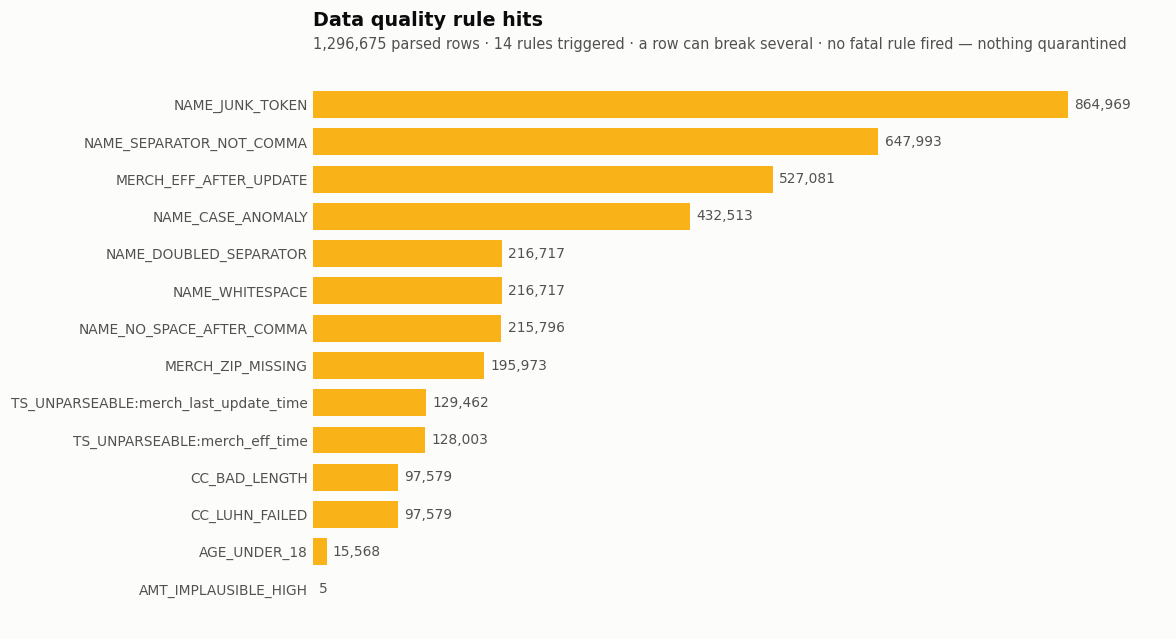

In [23]:
fig, ax = plt.subplots(figsize=(10, 0.36 * len(flag_counts) + 1.6))

order = flag_counts.sort_values("count")
colors = [vz.STATUS["critical"] if s == "fatal" else vz.STATUS["warning"]
          for s in order["severity"]]

bars = ax.barh(order["rule"], order["count"], color=colors, height=0.72)
vz.label_bars(ax, bars, fmt="{:,.0f}", horizontal=True)

_n_fatal_rules = int((flag_counts["severity"] == "fatal").sum())
ax.set_title("Data quality rule hits")
vz.subtitle(
    ax,
    f"{n_in:,} parsed rows · {len(flag_counts)} rules triggered · a row can break several · "
    + (f"{_n_fatal_rules} fatal, {n_reject:,} rows quarantined"
       if _n_fatal_rules else "no fatal rule fired — nothing quarantined")
)
ax.set_xlabel("")
ax.set_xticks([])
ax.grid(False)
ax.spines["bottom"].set_visible(False)
ax.margins(x=0.13)

# Only legend the severities that are actually on the chart. A key advertising
# a colour that appears nowhere invites the reader to hunt for bars that do not
# exist -- and on this feed nothing is fatal, which the subtitle states outright
# rather than leaving as an absence to be inferred.
_severity_key = [
    ("fatal",   vz.STATUS["critical"], "Fatal — row quarantined"),
    ("warning", vz.STATUS["warning"],  "Warning — row kept, field degraded"),
]
_present = [(c, lbl) for sev, c, lbl in _severity_key if (flag_counts["severity"] == sev).any()]
if len(_present) > 1:
    ax.legend([plt.Rectangle((0, 0), 1, 1, color=c) for c, _ in _present],
              [lbl for _, lbl in _present], loc="lower right", ncol=1)

vz.save(fig, "01_dq_scorecard")
plt.show()


**Reading it.** **Nothing in this feed is fatal.** All fourteen triggered rules are warnings, both
quarantine tables are empty, and all 1,296,675 rows reach the analytics layer. The chart therefore
carries one colour, and the legend drops the unused one rather than advertising a category with no
bars.

That is a claim worth distrusting, so §4.7 checks it two ways rather than asserting it. A fatal rule
that is never *emitted* — a typo in `FATAL_FLAGS`, a renamed rule — produces exactly this picture:
an empty quarantine and a clean bill of health. So every flag name is registered as it is defined,
and the policy is asserted to name only rules that exist. Eleven fatal rules are wired and none of
them fires, which is different from eleven fatal rules being misspelled.

The reason none fires is that the fatal list guards the columns an analysis cannot proceed without —
a usable transaction timestamp, a usable amount, a usable label, a present card number, a unique
transaction reference — and this extract is intact on every one of them. `trans_date_trans_time` is
a single uniform format with no unparseable values; `amt` is always numeric; `is_fraud` is always
`0` or `1`; and there is not one duplicate or replayed `trans_num` in 1.3 million rows.

**What the warnings say is a different story.** Two thirds of rows carry a junk token in
`person_name`, half use a separator other than a comma, 40% have a merchant effective time after its
last update, and a tenth of each merchant timestamp column is truncated beyond recovery. This is not
a clean feed — it is a feed whose every defect is **recoverable**, which is precisely the
distinction the severity split exists to draw. A pipeline that only reported "0 rows rejected" would
be telling the truth and saying nothing.


In [24]:
# Quarantine is a deliverable, not a side effect. Write it with the reasons
# attached -- and preview it redacted, because this frame is still raw: §5 has
# not run yet, and `trans_num` is a direct identifier by this notebook's own
# taxonomy. The stored quarantine gets the full silver treatment in §8.
(
    reject_df
    .select("trans_num", "`Unnamed: 0`", "trans_date_trans_time_utc8", "amt", "dq_flags")
    .limit(10).toPandas()
    .pipe(redact)
)


,trans_num,Unnamed: 0,trans_date_trans_time_utc8,amt,dq_flags


---
## 5. PII handling

### 5.1 What is actually personal here

The columns split into three groups, and the split is what drives the treatment. Lumping them all
together as "PII" and hashing everything is the common mistake — it destroys analytical value on
the quasi-identifiers while leaving the direct identifiers only weakly protected.

| Group | Columns | Risk |
|---|---|---|
| **Direct identifiers** | `cc_num`, `person_name`, `first`, `last`, `street`, `trans_num` | Identify a person on their own. |
| **Quasi-identifiers** | `dob`, `zip`, `gender`, `job`, `lat`/`long`, `city`, `city_pop` | Identify nobody alone; identify almost anybody in combination. The classic result is that **ZIP + date of birth + gender is unique for a large majority of the US population** — so hashing the name and keeping those three achieves nothing. |
| **Non-personal** | `merchant`, `category`, `amt`, `is_fraud`, `cc_bic`, merchant geo | No treatment needed. `cc_bic` identifies the *issuing bank*, not the cardholder. |

`person_name` is on that first list and is **not** one of the brief's 26 columns: it is the source
`first` and `last` are derived from in §4.2, and once they exist it has no further job. Masking
`first` and `last` while carrying the unmasked string they came from beside them protects nothing —
the masked columns are simply a redundant copy of a value the table still holds in full. So it is
**dropped** at the silver boundary, and §5.6 asserts it is gone rather than trusting that it is.

### 5.2 The schema is a contract

The brief specifies 26 output columns. Protecting the data is therefore **not allowed to delete any
of them**, and two shortcuts that would are ruled out here:

- **Dropping a column** because it is sensitive. `street`, `first`, `last`, `cc_num` and `trans_num`
  are all in the required list; a table that omits them does not satisfy the spec, whatever its
  privacy properties. (`person_name` is not in that list, which is why dropping *it* is available
  and dropping the others is not.)
- **Concatenating several identifiers into one hash** and keeping only that. It is one line of code
  and it collapses five distinct columns into a single opaque string — a loss of schema, not a
  privacy control. The consumer can no longer tell a missing surname from a missing card number,
  and nothing can be masked at a different strength later.

So every treatment below is applied **in place, column by column**: the column keeps its name, its
position and its meaning, and only the *precision of the value* changes. Derived keys —
`card_token`, `cc_bin6`, `cc_last4`, `zip3`, `age_band` — are added **alongside** the originals,
never in place of them.

The identity key is `card_token`, keyed on the card number alone. A key built by concatenating
name + date of birth was the first thing tried and is measured and rejected in §5.5: those are the
dirtiest columns in the feed, so the key fragments one cardholder into several.

§5.6 ends with an explicit assertion that all 26 columns survived, that no prohibited identifier
came with them, and that the ones that stayed actually hold masked values.

### 5.3 Why a keyed HMAC and not `sha2()`

The obvious move is `sha2(cc_num, 256)`. It does not work.

A card number is 16 digits with a fixed 6-digit BIN and a Luhn-constrained last digit, so the real
search space is about **10⁹ candidates per BIN**. An attacker holding the hashes and a commodity GPU
enumerates that in seconds and recovers every card number. The hash is not a one-way function when
the input domain is small — it is a lookup table.

Adding a *published* salt does not help either, since the salt is in the same file as the hashes.

What does work is a **keyed** HMAC-SHA256 with a secret that is never stored alongside the data. The
attacker now has to guess a 256-bit key rather than a 10-digit number. Concretely:

- the key comes from the `PII_HMAC_KEY` environment variable, and there is **no fallback** —
  not in the notebook and not in `docker-compose.yml`, which declares the variable as required
  (`${PII_HMAC_KEY:?...}`) and refuses to start the container without it. A key that ships with the
  code is not a key: anyone holding the repository could reverse every token with it. So the cell
  below raises rather than warning, on an unset value, a known placeholder, or anything under 32
  characters. Failing closed is the correct behaviour for a secret that is about to pseudonymise
  real card numbers; `.env.example` shows how to generate one;
- key rotation is a deliberate operation — rotating changes every token, which breaks joins to
  previously published extracts, so it needs a versioned token column in production;
- the token is deterministic, which is the whole point: the same card yields the same token across
  runs and across tables, so cardholder-level analysis still works without any card number present.

The same reasoning applies to `trans_num`: it is a pseudonymous identifier, low-entropy, and is
tokenised the same way — **in its own column**, so the required `trans_num` field is still there and
still joins to the quarantine table.

### 5.3a The quarantine is not an exemption

A row that failed a data-quality rule is still somebody's transaction. The earlier version of this
notebook wrote `quarantine_failed_rules` straight from the pre-PII frame, so the table that was
meant to record *rule failures* also carried raw card numbers, raw names, street addresses and raw
transaction references — the single largest identifier leak in the pipeline, sitting in the one
output nobody thinks of as a data product.

It is now written through **exactly the same silver treatment as the clean rows** (§5.5), so the
protection cannot drift between the two paths: one function, two callers. Nothing is lost for its
actual purpose, because the quarantine exists to show *which rule broke and on what shaped value* —
`dq_flags` plus the degraded field — and none of that needs a real name attached.

The bronze layer is where unmodified raw data legitimately lives, and it is the one layer this
notebook does not write: it belongs on restricted storage with a retention clock, not in
`data/curated/` beside the tables analysts read.


In [25]:
# The tokenisation key. There is no default and no fallback: this notebook
# processes a real cardholder feed, and a key that ships with the code is not a
# key -- anyone holding the repository could reverse every token with it.
#
# Failing here is the correct behaviour. An unset secret should stop a pipeline
# that is about to pseudonymise real card numbers, not warn and continue.
PII_HMAC_KEY = os.environ.get("PII_HMAC_KEY", "")

WEAK_KEYS = {"", "local-dev-key-not-for-production", "changeme", "secret", "test"}
if PII_HMAC_KEY in WEAK_KEYS or len(PII_HMAC_KEY) < 32:
    raise RuntimeError(
        "PII_HMAC_KEY is unset, a known placeholder, or shorter than 32 characters.\n"
        "Tokens are only as strong as this secret — a card number has ~10^9 candidates "
        "per BIN, so a guessable key makes the tokens reversible on a laptop.\n\n"
        "Generate one and pass it in, from a secret store in anything but a local run:\n"
        '    PII_HMAC_KEY="$(openssl rand -hex 32)" docker compose up'
    )

print(f"PII_HMAC_KEY loaded from the environment ({len(PII_HMAC_KEY)} chars, never printed)")


@pandas_udf(T.StringType())
def hmac_token(values: pd.Series) -> pd.Series:
    key = PII_HMAC_KEY.encode()          # captured once per executor, not per row
    def tok(v):
        if v is None:
            return None
        return hmac_lib.new(key, str(v).encode(), hashlib.sha256).hexdigest()[:32]
    return values.map(tok)


print("HMAC-SHA256 tokeniser ready (truncated to 128 bits — still far beyond brute force)")


PII_HMAC_KEY loaded from the environment (64 chars, never printed)
HMAC-SHA256 tokeniser ready (truncated to 128 bits — still far beyond brute force)


### 5.4 Three layers, three audiences

Rather than one "cleaned" table, the pipeline emits three, each readable by a wider group than the
last. This is the part that makes the policy enforceable: access control has something to attach to.
**Silver and gold both carry the full 26-column schema** — what changes between them is the
precision of the values, not the shape of the table. Bronze is the exception by definition: it is
the feed exactly as it arrived, 15 top-level fields with the nesting still in place and no derived
`first`/`last` at all, because deriving them would already be a transformation.

| Layer | Contents | Who reads it |
|---|---|---|
| **Bronze — raw** | Exactly what arrived, untouched. | Nobody routinely. Retained for replay and audit, on restricted storage with a retention clock. |
| **Silver — curated** | Direct identifiers masked or tokenised in place. Quasi-identifiers still exact. | Engineers and fraud investigators who need to reach a specific cardholder through a case-management system. |
| **Gold — analytics** | Silver, plus quasi-identifiers generalised in place. | Analysts, dashboards, notebooks like the rest of this one. |

Column by column:

| Required column | Silver | Gold | Signal retained |
|---|---|---|---|
| `cc_num` | `374512******2099` | unchanged from silver | Issuer (BIN) and the last four, which is the form every statement and support call uses. |
| `first`, `last` | `J*****`, `R****` | unchanged from silver | Length and initial only — enough to eyeball a masked row, not enough to name anyone. Grouping moves to `card_token`. |
| `street` | `[REDACTED]` | unchanged from silver | Nothing. A house number plus street is a direct identifier with no analytical use; the column survives, the value does not. |
| `trans_num` | HMAC token | unchanged from silver | Row identity and joins, without exposing the original reference. |
| `dob` | exact | truncated to **year of birth** | Age effects, via the `age_band` column derived beside it. |
| `zip` | exact | `468**` — ZIP3, suppressed to `000**` under 20,000 population | Regional geography. Mirrors the HIPAA Safe Harbor rule. |
| `lat`, `long` | exact | rounded to 1 dp (≈ 11 km) | Distance-to-merchant, which is the actual feature of interest, survives 11 km rounding intact. |
| `gender`, `job`, `city`, `city_pop`, `state` | exact | exact | Kept whole. Individually weak identifiers at this granularity; it is the *combination* with `zip` and `dob` that is dangerous, and that combination is what the gold layer breaks. |
| everything else | exact | exact | Non-personal. |

**What this does not do.** Tokenisation and generalisation reduce re-identification risk; they do
not eliminate it. A cardholder with a distinctive transaction pattern remains findable by anyone
holding an auxiliary dataset. Genuine guarantees need differential privacy or k-anonymity enforced
with suppression, and both cost accuracy. The right call for a fraud-analytics table is this
layering plus access control, with the residual risk written down rather than assumed away.

### 5.5 Choosing the identity key — and what the measurement actually said

Tokenising `cc_num` removes the card number but analysis still needs to ask *how many distinct
people are in here*. That needs a stable key, and there are two candidates: the cardholder
(`HMAC(first | last | dob)`) and the card (`HMAC(cc_num)`).

**The expected answer was that the name key fragments identities. On this feed it does not.** The
cell below measures it: 904 cards produce exactly 904 name-and-DOB keys, a 1.00× ratio, with every
card resolving to a single identity. `dob` is never null here and never malformed, and the names —
though 83% of them need repair — repair *consistently*, so the same person yields the same key every
time. The argument that the name key shatters into duplicate cardholders is a real failure mode, it
is simply not this file's failure mode, and reporting it as though the measurement had confirmed it
would be inventing evidence.

The card is still the right key, for two reasons that survive the measurement going the other way:

- **The 1.00× ratio is a property of this extract, not a guarantee.** It rests on `dob` being
  complete and on the repair rules in §4.2 being exactly right for all six name encodings. Both are
  true today and neither is promised by the producer; a seventh encoding next month would fragment
  the key silently, and a distinct count is exactly the kind of number nobody re-validates.
- **It derives an identity from more personal data than the job needs.** A key built from name and
  date of birth is a key built from three direct and quasi-identifiers, in a pipeline whose whole
  §5 is about touching those as little as possible. The card number is one field and is already
  being tokenised.

**The card key has its own failure mode, and that one the data does confirm.** §4.3 flags card
numbers that fail the Luhn checksum as *warnings* — the row is still analysable, so it stays — and
those damaged numbers were being tokenised like any other. A card whose digits were corrupted in
transit hashes to a token unrelated to the card it actually is, so it joins the table as an **extra
cardholder who does not exist**. Here that is 97,579 rows carrying 79 phantom cards, which would
have reported 983 cardholders instead of 904.

The fix is to say so in the data rather than in a caveat: `card_token` is **NULL** where the card
number did not pass its own checksum, with a `card_identity_reliable` boolean beside it. A null key
is not a missing feature — it is the accurate statement that this row cannot be attributed to a
card. Since `count(DISTINCT ...)` ignores nulls, every card-level metric in the notebook becomes
correct by construction rather than by remembering to filter. The rows themselves stay: an amount,
an hour and a label are untouched by a bad check digit, so they remain in every *transaction*-level
figure. Only the identity is withheld.

One caveat that no key fixes: **a card is not a person.** One person holding two cards counts twice,
so every "cardholder" figure below is an upper bound.


In [26]:
# Name-and-DOB key vs card key, on the same rows. This is the evidence for the
# choice made in the cell below.
#
# Restricted to cards that pass their own Luhn checksum: a corrupted card number
# is already a broken identity, and leaving those rows in would credit the name
# key with fragmentation the card key had too. The comparison has to be run on
# ground both keys stand on.
CARD_IDENTITY_RELIABLE = F.coalesce(F.col("cc_luhn_valid"), F.lit(False))

name_key = F.concat_ws(
    "|",
    F.coalesce(F.col("first"), F.lit("")),
    F.coalesce(F.col("last"), F.lit("")),
    F.coalesce(F.date_format("dob", "yyyy-MM-dd"), F.lit("")),
)

probe = clean_df.filter(CARD_IDENTITY_RELIABLE).withColumn("_name_key", name_key)

n_cards = probe.select("cc_num").distinct().count()
n_names = probe.select("_name_key").distinct().count()

# How many distinct name-keys does a single card produce? Anything above 1 is a
# person who has been split in two.
frag = (
    probe.groupBy("cc_num")
         .agg(F.countDistinct("_name_key").alias("identities"))
         .groupBy("identities").count().orderBy("identities")
         .toPandas()
)

print(f"distinct cards (Luhn-valid cc_num): {n_cards:,}")
print(f"distinct name+dob keys            : {n_names:,}"
      f"   <- {n_names / n_cards:.2f}x inflation\n")
print("name+dob keys produced per card:")
print(frag.to_string(index=False))
print(f"\ncards that survive as ONE identity: "
      f"{int(frag.loc[frag['identities'] == 1, 'count'].sum()):,} of {n_cards:,}")

# The defects behind it, for the record.
print("\nwhy — the inputs the name key is built from:")
print(clean_df.groupBy("name_quality").count().orderBy(F.desc("count")).toPandas().to_string(index=False))
print(f"rows with a NULL dob: {clean_df.filter(F.col('dob').isNull()).count():,}")

# And the card key's own failure mode, measured rather than assumed.
_unreliable = clean_df.filter(~CARD_IDENTITY_RELIABLE)
print(f"\nrows whose card number fails its own checksum: {_unreliable.count():,}")
print(f"distinct cc_num among them (phantom cards if tokenised): "
      f"{_unreliable.select('cc_num').distinct().count():,}")


distinct cards (Luhn-valid cc_num): 904
distinct name+dob keys            : 904   <- 1.00x inflation

name+dob keys produced per card:
 identities  count
          1    904

cards that survive as ONE identity: 904 of 904

why — the inputs the name key is built from:


name_quality   count
    REPAIRED 1080506
          OK  216169


rows with a NULL dob: 0



rows whose card number fails its own checksum: 97,579


distinct cc_num among them (phantom cards if tokenised): 79


In [27]:
# ---- SILVER: protect the direct identifiers, in place ------------------
# Order matters and is the whole trick: the derived keys are computed FIRST,
# from the real values, and the masks are applied AFTER, overwriting the same
# column names. The only column that leaves is `person_name` -- the raw string
# `first` and `last` were derived from, which is not one of the brief's 26 and
# whose continued presence would make masking those two pointless.

# Format-preserving mask. The BIN identifies the issuer, not the person, and the
# last four is the form cardholders and support staff actually recognise; the
# ten digits in between are what make the number usable, so they are the ten
# that go. The short branch covers CC_BAD_LENGTH rows, which are warnings rather
# than fatal and so are still here.
cc_masked = F.expr("""
    CASE WHEN cc_num IS NULL THEN NULL
         WHEN length(cc_num) >= 11
             THEN concat(substring(cc_num, 1, 6),
                         repeat('*', length(cc_num) - 10),
                         substring(cc_num, -4, 4))
         ELSE repeat('*', length(cc_num))
    END
""")

def mask_name(colname):
    # "Sanchez" -> "S******". Keeping the initial and the length makes a masked
    # row readable for QA without making it identifying.
    return F.expr(
        f"CASE WHEN `{colname}` IS NULL THEN NULL "
        f"ELSE concat(substring(`{colname}`, 1, 1), "
        f"            repeat('*', greatest(length(`{colname}`) - 1, 0))) END"
    )

# Raw direct identifiers that are NOT in the brief's 26 columns, and so have no
# reason to reach any stored layer once what is derived from them exists.
RAW_IDENTIFIER_COLUMNS = ["person_name", "person_name__raw"]


def to_silver_tier(frame):
    """Direct identifiers masked or tokenised in place; quasi-identifiers exact.

    One function, two callers -- the clean rows and the quarantine -- so the two
    paths cannot drift apart and a failed data-quality rule cannot become a way
    around the PII policy (§5.3a).
    """
    out = (
        frame
        # -- identity key, from the unmasked card number, and only where the
        #    card number passed its own checksum (§5.5). NULL is the honest
        #    value for "this row cannot be attributed to a card".
        .withColumn("card_identity_reliable", CARD_IDENTITY_RELIABLE)
        .withColumn("card_token",
                    F.when(CARD_IDENTITY_RELIABLE, hmac_token(F.col("cc_num"))))
        .withColumn("cc_bin6", F.substring(F.col("cc_num"), 1, 6))
        .withColumn("cc_last4", F.substring(F.col("cc_num"), -4, 4))
        # -- masks, overwriting the same columns --
        .withColumn("cc_num", cc_masked)
        .withColumn("trans_num", hmac_token(F.col("trans_num")))
        .withColumn("first", mask_name("first"))
        .withColumn("last", mask_name("last"))
        .withColumn("street", F.when(F.col("street").isNotNull(), F.lit("[REDACTED]")))
        # -- the raw source of first/last does not continue --
        .drop(*[c for c in RAW_IDENTIFIER_COLUMNS if c in frame.columns])
    )

    # -- the timestamp delivery contract ---------------------------------
    # Up to here the three time columns have carried a typed Spark `timestamp`,
    # which is the right thing to compute on but renders in the session zone
    # (UTC). The brief asks for those NAMED columns to be human-readable UTC+8.
    # So at the delivery boundary they are swapped: the brief's name takes the
    # UTC+8 string built in §4.1, and the canonical instant moves to
    # `<col>_utc`, still typed and still what every later calculation uses.
    for c in TIME_COLUMNS:
        out = (
            out
            .withColumnRenamed(c, f"{c}_utc")      # typed instant, kept for maths
            .withColumnRenamed(f"{c}_utc8", c)     # the brief's column, UTC+8 string
        )
    return out


silver_df = to_silver_tier(clean_df).cache()

dropped = set(clean_df.columns) - set(silver_df.columns) - {f"{c}_utc8" for c in TIME_COLUMNS}
required_lost = [c for c in TARGET_COLUMNS if c not in silver_df.columns]
print(f"silver: {silver_df.count():,} rows x {len(silver_df.columns)} columns")
print(f"dropped (raw identifiers, none of them required): {sorted(dropped)}")
print(f"required columns lost: {required_lost or 'none'}")
print(f"added: {sorted(set(silver_df.columns) - set(clean_df.columns) - {f'{c}_utc' for c in TIME_COLUMNS})}")

_n_rel = silver_df.filter(F.col("card_identity_reliable")).count()
print(f"\ncard identity: {_n_rel:,} of {silver_df.count():,} rows carry a card_token "
      f"({silver_df.count() - _n_rel:,} withheld — card number failed its checksum)")

silver_df.select("cc_num", "cc_bin6", "cc_last4", "card_token", "card_identity_reliable",
                 "first", "last", "street", "trans_num",
                 "trans_date_trans_time", "trans_date_trans_time_utc").limit(5).toPandas()


silver: 1,296,675 rows x 40 columns
dropped (raw identifiers, none of them required): ['person_name']
required columns lost: none
added: ['card_identity_reliable', 'card_token', 'cc_bin6', 'cc_last4']



card identity: 1,199,096 of 1,296,675 rows carry a card_token (97,579 withheld — card number failed its checksum)


,cc_num,cc_bin6,cc_last4,card_token,card_identity_reliable,first,last,street,trans_num,trans_date_trans_time,trans_date_trans_time_utc
0,303283****0870,303283,0870,c27e3876c144d02c7b499c5e3149b782,True,H****,C*******,[REDACTED],69089ea6373c75370ee3410507901be6,2019-09-13 21:23:23.000000 +0800,2019-09-13 13:23:23
1,601149******2597,601149,2597,44d45b82eaf8f42db5057740252506c0,True,G***,B*****,[REDACTED],ed6f27e02fc9e342e1a6ef2bfd241cad,2020-03-18 05:50:21.000000 +0800,2020-03-17 21:50:21
2,604905*6305,604905,6305,None,False,K****,J******,[REDACTED],d947a5b2c943e2944dd6f072492b6a3a,2019-12-29 10:56:45.000000 +0800,2019-12-29 02:56:45
3,213186*****9195,213186,9195,3bf8714acd1a91dfca697da78a3459a3,True,C****,F*****,[REDACTED],bfcc67f90c753f18df46ff87061d1471,2019-01-25 01:15:12.000000 +0800,2019-01-24 17:15:12
4,659325******7804,659325,7804,94851ea851f14763795996aa34eb8fce,True,M******,M***,[REDACTED],1ab9d4cdc713849a7627bf6a5e7ed29c,2019-10-11 21:36:07.000000 +0800,2019-10-11 13:36:07


In [28]:
# ---- GOLD: generalise the quasi-identifiers, also in place -------------
# HIPAA Safe Harbor suppresses ZIP3 areas with fewer than 20,000 people. Using
# the feed's own population figure as the proxy.
zip3 = F.when(F.col("city_pop") >= 20000, F.substring(F.col("zip"), 1, 3)).otherwise(F.lit("000"))

age_band = (
    F.when(F.col("age") < 25, "18-24")
     .when(F.col("age") < 35, "25-34")
     .when(F.col("age") < 45, "35-44")
     .when(F.col("age") < 55, "45-54")
     .when(F.col("age") < 65, "55-64")
     .when(F.col("age") < 75, "65-74")
     .when(F.col("age") >= 75, "75+")
)

gold_df = (
    silver_df
    # -- the analysis-friendly generalisations, added beside the originals --
    .withColumn("zip3", zip3)
    .withColumn("age_band", age_band)
    # -- the originals, coarsened in place rather than removed --
    # zip keeps five characters so it still reads as a ZIP: "46805" -> "468**".
    .withColumn("zip", F.when(F.col("zip").isNotNull(), F.concat(F.col("zip3"), F.lit("**"))))
    # dob stays a date, at year-of-birth precision: 1985-03-14 -> 1985-01-01.
    .withColumn("dob", F.trunc(F.col("dob"), "year"))
    # ~11 km at 1 dp — below the resolution at which distance-to-merchant matters.
    .withColumn("lat", F.round(F.col("lat"), 1))
    .withColumn("long", F.round(F.col("long"), 1))
    .cache()
)

lost = set(silver_df.columns) - set(gold_df.columns)
print(f"gold: {gold_df.count():,} rows x {len(gold_df.columns)} columns, {len(lost)} dropped ({lost or 'none'})")

gold_df.select("card_token", "dob", "age_band", "zip", "zip3", "gender",
               "lat", "long", "amt", "category", "is_fraud").limit(5).toPandas()

gold: 1,296,675 rows x 42 columns, 0 dropped (none)


,card_token,dob,age_band,zip,zip3,gender,lat,long,amt,category,is_fraud
0,c27e3876c144d02c7b499c5e3149b782,1954-01-01,65-74,000**,000,F,40.0,-93.2,60.19,health_fitness,0
1,44d45b82eaf8f42db5057740252506c0,1986-01-01,25-34,000**,000,M,33.3,-92.7,66.16,food_dining,0
2,None,1963-01-01,55-64,000**,000,F,34.9,-90.8,147.80,grocery_pos,0
3,3bf8714acd1a91dfca697da78a3459a3,1973-01-01,45-54,000**,000,M,40.5,-90.3,535.51,travel,0
4,94851ea851f14763795996aa34eb8fce,1977-01-01,35-44,334**,334,F,26.7,-80.3,389.40,misc_pos,0


### 5.6 The schema contract, verified

The claim made in §5.2 is that PII handling changed values, added columns, and removed only the one
column that is not in the brief. That is checkable, so it is checked rather than asserted. The cell
below fails loudly on any of four things:

1. **a required column is missing** from the analytics layer;
2. **a prohibited raw identifier is present** — `person_name` or its untrimmed twin. A column-name
   check is cheap and catches the exact leak that shipped in the previous version of this notebook,
   where `person_name` rode into both stored layers beside the masked `first` and `last` that were
   derived from it;
3. **a retained identifier still holds a raw value.** Names are the easy half: a column can keep its
   name and still carry an unprotected value, so every direct identifier is matched against the
   *shape* its treatment should have produced — `cc_num` as BIN-stars-last4, `first`/`last` as
   initial-plus-stars, `street` as the literal redaction, `trans_num` as 32 hex characters. This is
   the assertion that would have caught the original bug on its own;
4. **a timestamp is not delivered as specified** — the three time columns are asserted to match the
   brief's `YYYY-MM-DD HH:MM:SS.SSSSSS ±HHMM` rendering at UTC+8, under the names the brief gave
   them, with the typed instant still beside them.

The same check is applied to the quarantine table in §8, because that is the other thing this
notebook writes to disk.


In [29]:
# Treatment applied to each required column. Anything not listed is carried
# through unchanged because it is not personal data.
PII_TREATMENT = {
    "cc_num":    "masked in place — BIN + last 4",
    "first":     "masked in place — initial + length",
    "last":      "masked in place — initial + length",
    "street":    "redacted in place",
    "trans_num": "HMAC-SHA256 token in place",
    "dob":       "generalised in place — year of birth",
    "zip":       "generalised in place — ZIP3 + suppression",
    "lat":       "generalised in place — 1 dp (~11 km)",
    "long":      "generalised in place — 1 dp (~11 km)",
}
TIME_TREATMENT = {c: "rendered in place — UTC+8 string" for c in TIME_COLUMNS}

# Raw identifiers that must not appear in any stored layer.
PROHIBITED_COLUMNS = ["person_name", "person_name__raw"]

# The shape each direct identifier must have AFTER treatment. Checking the value
# and not just the column name is the point: the leak this guards against was a
# correctly-masked `first` sitting next to a fully raw `person_name`, and every
# column-count check in the notebook passed while it did.
IDENTIFIER_SHAPE = {
    "cc_num":    r"^(\d{6}\*+\d{4}|\*+)$",
    "first":     r"^.\**$",
    "last":      r"^.\**$",
    "street":    r"^\[REDACTED\]$",
    "trans_num": r"^[0-9a-f]{32}$",
}


def assert_identifiers_protected(frame, label):
    """Fail loudly if `frame` carries a raw direct identifier. Applied to every
    layer this notebook writes — silver, gold and the quarantine."""
    leaked = [c for c in PROHIBITED_COLUMNS if c in frame.columns]
    assert not leaked, f"{label}: prohibited raw identifier column present: {leaked}"

    present = {c: p for c, p in IDENTIFIER_SHAPE.items() if c in frame.columns}
    counts = frame.select([
        F.sum((F.col(f"`{c}`").isNotNull() & ~F.col(f"`{c}`").rlike(p)).cast("long")).alias(c)
        for c, p in present.items()
    ]).collect()[0].asDict()
    unprotected = {c: int(n) for c, n in counts.items() if n}
    assert not unprotected, f"{label}: direct identifiers not protected: {unprotected}"
    print(f"{label:<26} no prohibited columns · {len(present)} identifiers match their masked shape")


# 1 + 2 + 3 — the identifier contract, on both stored analytical layers.
assert_identifiers_protected(silver_df, "silver")
assert_identifiers_protected(gold_df, "gold")

# 1 — the 26-column contract.
missing = [c for c in TARGET_COLUMNS if c not in gold_df.columns]
assert not missing, f"required columns lost to PII handling: {missing}"

# 4 — the timestamp contract, asserted rather than eyeballed.
UTC8_PATTERN = r"^\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}\.\d{6} \+0800$"
for c in TIME_COLUMNS:
    assert dict(gold_df.dtypes)[c] == "string", f"{c} is not the delivered UTC+8 rendering"
    bad = gold_df.filter(F.col(c).isNotNull() & ~F.col(c).rlike(UTC8_PATTERN)).count()
    assert bad == 0, f"{c}: {bad:,} values do not match the brief's UTC+8 format"
    assert dict(gold_df.dtypes)[f"{c}_utc"] == "timestamp", f"{c}_utc lost its type"

_sample = (
    gold_df
    .select([F.col(f"`{c}`").cast("string").alias(c) for c in TARGET_COLUMNS])
    .limit(1).toPandas().iloc[0]
)

contract = pd.DataFrame({
    "required column": TARGET_COLUMNS,
    "treatment": [PII_TREATMENT.get(c, TIME_TREATMENT.get(c, "carried through unchanged"))
                  for c in TARGET_COLUMNS],
    "example value": [_sample[c] for c in TARGET_COLUMNS],
})

added = sorted(set(gold_df.columns) - set(clean_df.columns) - {f"{c}_utc" for c in TIME_COLUMNS})
print(f"\nall {len(TARGET_COLUMNS)} required columns present")
print(f"{len(PII_TREATMENT)} PII-treated in place, {len(TIME_TREATMENT)} rendered to UTC+8, "
      f"{len(TARGET_COLUMNS) - len(PII_TREATMENT) - len(TIME_TREATMENT)} unchanged")
print(f"dropped as a non-required raw identifier: {PROHIBITED_COLUMNS[0]}")
print(f"timestamp contract: all three columns match {UTC8_PATTERN}")
print(f"derived columns added alongside: {added}")
contract


silver                     no prohibited columns · 5 identifiers match their masked shape


gold                       no prohibited columns · 5 identifiers match their masked shape



all 26 required columns present
9 PII-treated in place, 3 rendered to UTC+8, 14 unchanged
dropped as a non-required raw identifier: person_name
timestamp contract: all three columns match ^\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}\.\d{6} \+0800$
derived columns added alongside: ['age_band', 'card_identity_reliable', 'card_token', 'cc_bin6', 'cc_last4', 'zip3']


,required column,treatment,example value
0,Unnamed: 0,carried through unchanged,602698
1,trans_date_trans_time,rendered in place — UTC+8 string,2019-09-13 21:23:23.000000 +0800
2,cc_num,masked in place — BIN + last 4,303283****0870
3,merchant,carried through unchanged,Heller PLC
4,category,carried through unchanged,health_fitness
5,amt,carried through unchanged,60.19
6,first,masked in place — initial + length,H****
7,last,masked in place — initial + length,C*******
8,gender,carried through unchanged,F
9,street,redacted in place,[REDACTED]


### 5.7 Did the generalisation actually do anything?

`ZIP + date of birth + gender` is the textbook re-identification vector, so the honest test is to
measure it before and after rather than assert that generalisation worked.

**What `k` counts matters here.** A naive count groups *transactions*, and a combination held by one
transaction is not the same as a combination held by one person — a cardholder with forty
transactions would look forty times safer than they are. So the cell below reports both: rows per
combination, and **distinct cards** per combination. The card figure is the one that bears on
re-identification.

It is measured over the rows that carry a `card_token`, i.e. the ones with a reliable card identity
(§5.5). A row whose card number failed its checksum cannot be attributed to a card at all, so it can
neither raise nor lower a per-card k — counting it as its own anonymous cardholder would make the
table look *more* anonymous than it is, which is the direction an error must never go.


In [30]:
# Re-identification exposure, before and after generalisation.
#
# k-anonymity is a property of the RELEASED table, so it is measured on the
# released rows — but a combination is only a successful re-identification if it
# isolates a PERSON, so distinct cards per combination is reported next to it.
def uniqueness(frame, cols, label):
    # Only rows with a reliable card identity — see the note above.
    grp = frame.filter(F.col("card_token").isNotNull()).groupBy(*cols).agg(
        F.count("*").alias("rows"),
        F.countDistinct("card_token").alias("cards"),
    )
    tot = grp.count()
    r1 = grp.filter(F.col("rows") == 1).count()
    c1 = grp.filter(F.col("cards") == 1).count()
    c5 = grp.filter(F.col("cards") < 5).count()
    print(f"{label:<32} combos={tot:>7,}  rows k=1:{r1:>7,}  "
          f"cards k=1:{c1:>7,}  cards k<5:{c5:>7,}")

print("a 'combo' is one value of the quasi-identifier triple below\n")
uniqueness(silver_df, ["zip", "dob", "gender"],        "exact zip + dob + gender")
uniqueness(gold_df,   ["zip3", "age_band", "gender"],  "zip3 + age_band + gender")

# .distinct().count() would count NULL as a card of its own — the exact
# mistake this column exists to prevent. countDistinct ignores NULL.
_cards = gold_df.select(F.countDistinct("card_token")).collect()[0][0]
_rows_no_id = gold_df.filter(F.col("card_token").isNull()).count()
print(f"\ncards in the released table: {_cards:,}")
print(f"rows with no attributable card identity: {_rows_no_id:,} "
      f"({_rows_no_id / gold_df.count():.2%} — excluded from every card-level figure)")


a 'combo' is one value of the quasi-identifier triple below



exact zip + dob + gender         combos=    904  rows k=1:      0  cards k=1:    904  cards k<5:    904


zip3 + age_band + gender         combos=    278  rows k=1:      0  cards k=1:    258  cards k<5:    264



cards in the released table: 904


rows with no attributable card identity: 97,579 (7.53% — excluded from every card-level figure)


**Reading it, and the answer is not the flattering one.** `cards k=1` counts quasi-identifier
combinations held by exactly one card — each is a successful re-identification for anyone holding a
matching external record.

Generalisation moved the number, and nowhere near far enough. `zip + dob + gender` isolates a single
card in **all 904** combinations, which is the textbook result and the reason the gold layer exists.
After generalising to `zip3 + age_band + gender`, there are 278 combinations and **258 of them still
isolate exactly one card** — 93%. The gold layer is **not k-anonymous**, and calling ZIP3 and age
banding a privacy control here would be false comfort.

The reason is arithmetic rather than a bug in the generalisation: 904 cards spread across 3-digit ZIP
prefixes, 7 age bands and 2 genders simply cannot be crowded. k-anonymity needs *population* in each
cell, and this extract does not have it. On the full cardholder base those same rules would behave
very differently — which is the point: **k is a property of the released table, so it has to be
measured on the release, not inherited from the policy that produced it.**

What that means for this table:

- It is **not** safe to publish broadly on the strength of the generalisation alone. The layering in
  §5.4 buys real protection against the *direct* identifiers — those are tokenised and masked, and
  §5.6 asserts it — but the quasi-identifiers still single people out.
- Getting to a genuine k ≥ 5 would need suppression with teeth: drop `zip` entirely, widen the age
  bands, or suppress combinations below the threshold and accept the missing rows. All three cost
  analysis, and which to spend is a decision for whoever owns the risk, not for the notebook.
- Until then the control that is actually doing the work is **access**, not anonymisation — which is
  why §5.4 pairs the layers with who may read them rather than presenting gold as safe by
  construction.

**And the triple is not the whole attack surface.** k was measured on `zip + dob + gender` because
that is the textbook vector, but `job` is carried through to gold **exact**, and it holds 494
distinct values across 904 cards — roughly one occupation per two cardholders. A quasi-identifier
that selective is very likely a stronger re-identification key than the triple that was measured,
and the same is true of `city` at this population size. So the 258-of-278 figure above is a **lower
bound on exposure**, not an estimate of it: measuring more columns can only make it worse. Any real
release decision needs k computed over the full set of quasi-identifiers a recipient could join on,
not over the three that are conventional to check.

`rows k=1` is shown beside it only to make the difference explicit. It is the friendlier number and
it is the wrong one: it counts transactions, so a cardholder with forty of them looks forty times
safer than they are.


---
## 6. Feature engineering

Four derived features, each intended to answer a question the raw columns cannot.

**`distance_km`** — great-circle distance between the cardholder's home and the merchant, via the
haversine formula. Written as Spark SQL rather than a UDF so it stays inside the JVM and the Catalyst
optimiser can see it. This is the single most useful engineered feature for card-present fraud:
a card physically present 900 km from its home address is a strong signal.

**`hour_utc8` / `dow_utc8`** — the hour and weekday of the transaction **in the UTC+8 rendering the
brief asks for**, extracted from the typed instant rather than from the delivered string.

The naming here is deliberate and the earlier version got it wrong. These used to be called
`local_hour` and `local_dow`, and §7 read the result as the cardholder's local clock — which the
data does not support. Every address in this feed is in the United States, and
`trans_date_trans_time` carries no offset at all (§4.1), so "UTC+8" is a *rendering* the brief
specified, not a zone anyone in the data lives in. Calling the bucket `local_hour` turns a
presentation choice into a claim about when a cardholder was awake, and every conclusion drawn from
it inherits that claim silently. The column says what it is: the hour at UTC+8.

**`merchant_tenure_days`** — how long the merchant had been registered when the transaction
happened, from `merch_eff_time`. This is a column the standard version of this dataset does not
carry.

**`amt_zscore_in_category`** — the amount relative to its own category's distribution, via a window.
A $200 grocery run and a $200 flight are not comparable in absolute terms; both are comparable as
deviations from their category norm.


In [31]:
def haversine_km(lat1, lon1, lat2, lon2):
    # Pure Spark expressions — no Python round trip.
    r = F.lit(6371.0)
    p1, p2 = F.radians(lat1), F.radians(lat2)
    dphi = p2 - p1
    dlmb = F.radians(lon2 - lon1)
    a = F.pow(F.sin(dphi / 2), 2) + F.cos(p1) * F.cos(p2) * F.pow(F.sin(dlmb / 2), 2)
    return r * 2 * F.asin(F.sqrt(a))


w_cat = Window.partitionBy("category")

feat_df = (
    gold_df
    .withColumn("distance_km",
                F.round(haversine_km(F.col("lat"), F.col("long"),
                                     F.col("merch_lat"), F.col("merch_long")), 2))
    # The typed instants, not the delivered UTC+8 strings — see §5.5. Named for
    # the offset they are rendered at, not for a cardholder's local clock, which
    # this feed does not establish (§4.1, §6 above).
    .withColumn("ts_utc8", F.from_utc_timestamp("trans_date_trans_time_utc", DISPLAY_TZ))
    .withColumn("hour_utc8", F.hour("ts_utc8"))
    .withColumn("dow_utc8", F.date_format("ts_utc8", "E"))
    .withColumn("date_utc8", F.to_date("ts_utc8"))
    # The partition key -- month, not day. See §8 for why.
    .withColumn("month_utc8", F.date_format("ts_utc8", "yyyy-MM"))
    .withColumn("merchant_tenure_days",
                F.datediff(F.col("trans_date_trans_time_utc"), F.col("merch_eff_time_utc")))
    .withColumn("amt_zscore_in_category",
                F.round((F.col("amt") - F.avg("amt").over(w_cat))
                        / F.stddev("amt").over(w_cat), 3))
    .cache()
)

# --- is merchant_tenure_days actually a feature? ------------------------
# Asked rather than assumed. A derived column that turns out to be degenerate is
# worse than a missing one: it survives every schema check, plots as a single
# bar, and reads as a finding. In THIS extract merch_eff_time is the
# transaction timestamp shifted back by a fixed offset, so the difference
# between them is the same number on every row and the feature carries no
# information at all. That is a property of the extract, not of merchants.
_tenure = feat_df.select(
    F.countDistinct("merchant_tenure_days").alias("distinct_values"),
    F.min("merchant_tenure_days").alias("min_days"),
    F.max("merchant_tenure_days").alias("max_days"),
).toPandas().iloc[0]
print(f"{feat_df.count():,} rows ready for analysis\n")
print("merchant_tenure_days: "
      f"{int(_tenure['distinct_values']):,} distinct value(s), "
      f"range {int(_tenure['min_days']):,}..{int(_tenure['max_days']):,} days")
print("  -> merch_eff_time is a fixed offset from the transaction timestamp in this extract,\n"
      "     so the difference between them is the same number on every row. §7.5 tests whether\n"
      "     the banded version resolves into more than one band before plotting it.")
feat_df.select("ts_utc8", "hour_utc8", "dow_utc8", "distance_km",
               "merchant_tenure_days", "amt", "amt_zscore_in_category", "is_fraud").limit(6).toPandas()


1,296,675 rows ready for analysis

merchant_tenure_days: 2 distinct value(s), range 2,556..2,557 days
  -> merch_eff_time is a fixed offset from the transaction timestamp in this extract,
     so the difference between them is the same number on every row. §7.5 tests whether
     the banded version resolves into more than one band before plotting it.


,ts_utc8,hour_utc8,dow_utc8,distance_km,merchant_tenure_days,amt,amt_zscore_in_category,is_fraud
0,2019-12-29 10:56:45,10,Sun,51.67,NaN,147.80,0.580,0
1,2020-01-10 12:30:24,12,Fri,92.50,2556.0,110.22,-0.127,0
2,2020-01-03 16:04:20,16,Fri,73.68,2556.0,123.06,0.115,0
3,2019-07-10 19:45:28,19,Wed,88.99,2556.0,75.14,-0.786,0
4,2019-08-10 13:09:15,13,Sat,41.16,2556.0,131.78,0.278,0
5,2019-08-16 16:05:03,16,Fri,77.94,2556.0,96.97,-0.376,0


In [32]:
# Headline numbers, computed once and reused by the charts below.
#
# Fraud VALUE sums positive amounts only. §4.4 flags negative amounts as probable
# refunds that leaked into a purchase feed, and netting a refund against a real
# loss understates exposure — the two belong in different columns of the ledger,
# not the same sum. Zero-amount rows are excluded for the same reason. Neither is
# dropped: both are counted and printed, because "we excluded nine rows" is a
# claim that has to carry its number.
#
# `cards` counts distinct card_token, which is NULL wherever the card number
# failed its own checksum (§5.5) -- and count(DISTINCT ...) ignores NULL, so the
# tile counts cards the feed can actually identify rather than crediting every
# corrupted card number with a cardholder of its own.
_is_fraud = F.col("is_fraud") == 1

kpi = feat_df.agg(
    F.count("*").alias("txns"),
    F.countDistinct("card_token").alias("cards"),
    F.count(F.when(F.col("card_token").isNull(), True)).alias("rows_without_card_identity"),
    F.sum("amt").alias("total_amt"),
    F.sum("is_fraud").alias("fraud_txns"),
    F.sum(F.when(_is_fraud & (F.col("amt") > 0), F.col("amt")).otherwise(0.0)).alias("fraud_amt"),
    F.sum(F.when(_is_fraud & (F.col("amt") < 0), F.col("amt")).otherwise(0.0)).alias("fraud_refund_amt"),
    F.count(F.when(_is_fraud & (F.col("amt") < 0), True)).alias("fraud_negative_rows"),
    F.count(F.when(_is_fraud & (F.col("amt") == 0), True)).alias("fraud_zero_rows"),
    F.min("date_utc8").alias("from_date"),
    F.max("date_utc8").alias("to_date"),
).toPandas().iloc[0]

OVERALL_FRAUD_RATE = kpi["fraud_txns"] / kpi["txns"]
print(kpi.to_string())
print(f"\noverall fraud rate: {OVERALL_FRAUD_RATE:.3%}")
print(f"fraud value (positive amounts only) : ${kpi['fraud_amt']:,.2f}")
print(f"excluded from it: {int(kpi['fraud_negative_rows'])} negative rows "
      f"(${kpi['fraud_refund_amt']:,.2f}) and {int(kpi['fraud_zero_rows'])} zero-amount rows")
print(f"rows with no attributable card identity: {int(kpi['rows_without_card_identity']):,}")


txns                             1296675
cards                                904
rows_without_card_identity         97579
total_amt                     91222428.9
fraud_txns                          7506
fraud_amt                     3988088.61
fraud_refund_amt                     0.0
fraud_negative_rows                    0
fraud_zero_rows                        0
from_date                     2019-01-01
to_date                       2020-06-21

overall fraud rate: 0.579%
fraud value (positive amounts only) : $3,988,088.61
excluded from it: 0 negative rows ($0.00) and 0 zero-amount rows
rows with no attributable card identity: 97,579


---
## 7. Visualisation and analysis

Each figure below states what question it answers and why that chart form was chosen, because the
form is a decision and not a default. A few conventions hold throughout:

- **One axis per chart.** Two measures on two scales would be two charts, never two y-axes.
- **Colour is assigned by job.** Magnitude gets a single-hue sequential ramp; identity gets
  categorical slots in fixed order; the fraud *state* gets a reserved status colour. Colour never
  carries meaning alone — every chart with more than one series has both a legend and labels.
- **Every figure is accompanied by its table.** These are static images with no hover layer, so the
  underlying numbers are printed rather than hidden behind a tooltip.
- **Rates, not counts, wherever the base differs.** Fraud *counts* by category mostly measure how
  popular the category is. Fraud *rate* measures risk.


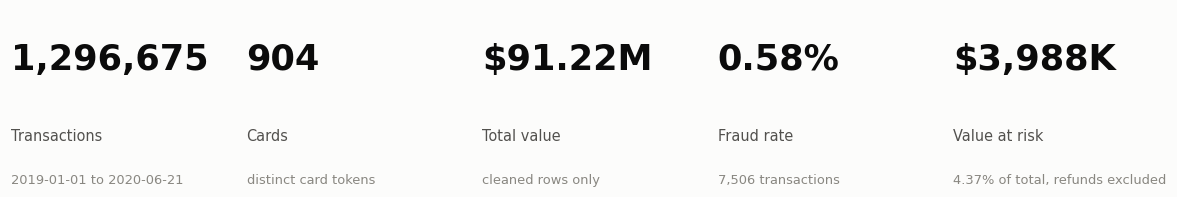

In [33]:
# Shared helper: fraud rate plus the base it is computed from. The base matters —
# a 40% fraud rate over five transactions is noise, and the table has to show it.
def fraud_rate_by(frame, col, min_base=50):
    pdf = (
        frame.groupBy(col)
        .agg(F.count("*").alias("txns"),
             F.sum("is_fraud").alias("fraud_txns"),
             F.sum(F.when((F.col("is_fraud") == 1) & (F.col("amt") > 0), F.col("amt"))
                   .otherwise(0.0)).alias("fraud_amt"),   # positive only — see the KPI cell
             F.avg("amt").alias("avg_amt"))
        .toPandas()
    )
    pdf["fraud_rate"] = pdf["fraud_txns"] / pdf["txns"]
    pdf["reliable"] = pdf["txns"] >= min_base
    return pdf


fig = vz.stat_tiles([
    ("Transactions",      f"{int(kpi['txns']):,}",        f"{kpi['from_date']} to {kpi['to_date']}"),
    ("Cards",             f"{int(kpi['cards']):,}",       "distinct card tokens"),
    ("Total value",       f"${kpi['total_amt']/1e6:,.2f}M", "cleaned rows only"),
    ("Fraud rate",        f"{OVERALL_FRAUD_RATE:.2%}",    f"{int(kpi['fraud_txns']):,} transactions"),
    ("Value at risk",     f"${kpi['fraud_amt']/1e3:,.0f}K", f"{kpi['fraud_amt']/kpi['total_amt']:.2%} of total, refunds excluded"),
])
vz.save(fig, "02_kpi_tiles")
plt.show()

> **Cards, not people — and only the cards the feed can identify.** The second tile counts distinct
> `card_token`, which is the most reliable identity this feed supports (§5.5). Two things bound it:
> one person holding two cards counts twice, so it is an **upper bound** on cardholders; and rows
> whose card number failed its checksum carry no token at all, so they are **not** counted as
> cardholders of their own. The count of those rows is printed above the tiles.

**Why tiles and not a chart.** Five single magnitudes with no comparison to draw between them. A bar
chart of unrelated quantities on one scale would imply a comparison that does not exist; the number
itself is the whole message.

Note the gap between the last two tiles: fraud is a small share of *transactions* and a visibly
larger share of *value*. That gap is the reason the rest of this section keeps separating rate from
value.


### 7.1 When does fraud happen?

**Question:** does the fraud rate vary by hour of day?
**Form:** a vertical bar chart over 24 ordered, evenly-spaced buckets. Hour-of-day is cyclical and
categorical-but-ordered, which is bar territory; a line would imply continuous interpolation between
02:00 and 03:00 that the aggregation does not support.
**Colour:** one measure, one hue. The overall rate is drawn as a labelled reference line rather than
as a second series, which keeps the chart on one axis and makes "above or below average" readable
without a legend.

**Read the x-axis literally.** It is the hour at **UTC+8**, the rendering the brief asks for. It is
not the cardholder's local hour, and this chart is where that distinction stops being pedantic — see
the finding below.


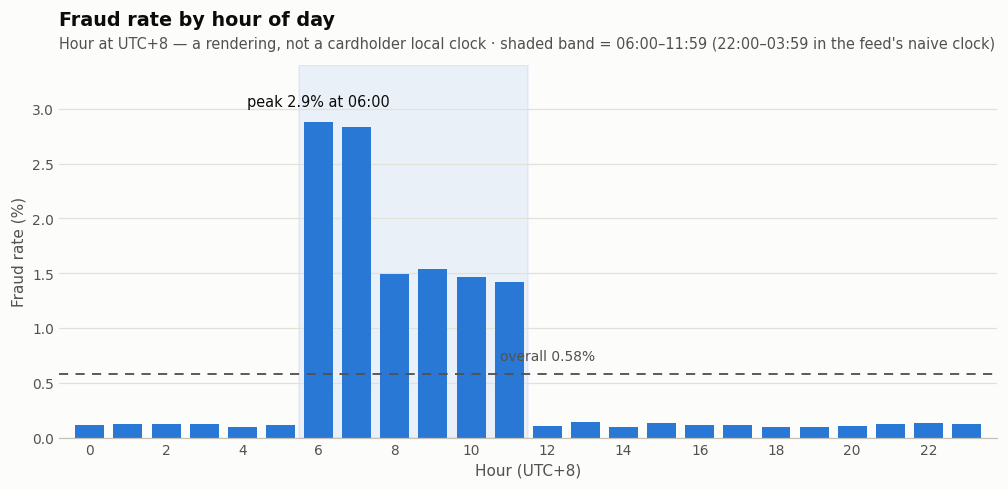

06:00–11:59  2.09% over 304,882 txns
other 18 h   0.12% over 991,793 txns
lift         18.1x
coverage     84.8% of all fraud on 23.5% of all traffic

 hour_utc8  txns  fraud_txns  fraud_rate
         0 65726          76    0.001156
         1 65450          78    0.001192
         2 66051          81    0.001226
         3 65508          81    0.001236
         4 65098          62    0.000952
         5 65533          74    0.001129
         6 66982        1931    0.028829
         7 67104        1904    0.028374
         8 42502         635    0.014940
         9 42869         658    0.015349
        10 42656         625    0.014652
        11 42769         609    0.014239
        12 41863          46    0.001099
        13 42171          60    0.001423
        14 42300          40    0.000946
        15 42203          56    0.001327
        16 42505          49    0.001153
        17 42185          47    0.001114
        18 42271          40    0.000946
        19 42082          42  

In [34]:
by_hour = fraud_rate_by(feat_df, "hour_utc8").sort_values("hour_utc8")

fig, ax = plt.subplots(figsize=(11, 4.4))
bars = ax.bar(by_hour["hour_utc8"], by_hour["fraud_rate"] * 100,
              color=vz.CATEGORICAL[0], width=0.76)

# The ELEVATED window, called out as an annotated band rather than a second
# colour. Read off the data rather than assumed: these are the six contiguous
# hours carrying the lift. An earlier version of this cell shaded 22:00-03:59
# -- the eight-hour-shifted image of the same block, which at UTC+8 is the
# QUIETEST stretch of the day -- and printed its 0.2x as though it were the
# finding. The band and the arithmetic below now share one definition, so they
# cannot drift apart again.
PEAK_HOURS = [6, 7, 8, 9, 10, 11]
ax.axvspan(min(PEAK_HOURS) - 0.5, max(PEAK_HOURS) + 0.5,
           color=vz.CATEGORICAL[0], alpha=0.09, zorder=0)

ax.axhline(OVERALL_FRAUD_RATE * 100, color=vz.INK["secondary"], linewidth=1.2, linestyle=(0, (5, 4)))
# Parked mid-afternoon, where the bars are short — at the right-hand edge it
# would sit on top of the 23:00 bar.
ax.annotate(f"overall {OVERALL_FRAUD_RATE:.2%}",
            xy=(12, OVERALL_FRAUD_RATE * 100), xytext=(0, 7), textcoords="offset points",
            ha="center", va="bottom", fontsize=9, color=vz.INK["secondary"])

peak = by_hour.loc[by_hour["fraud_rate"].idxmax()]
ax.annotate(f"peak {peak['fraud_rate']:.1%} at {int(peak['hour_utc8']):02d}:00",
            xy=(peak["hour_utc8"], peak["fraud_rate"] * 100),
            xytext=(0, 10), textcoords="offset points",
            ha="center", fontsize=9.5, color=vz.INK["primary"])

ax.set_title("Fraud rate by hour of day")
vz.subtitle(ax, "Hour at UTC+8 — a rendering, not a cardholder local clock · "
                "shaded band = 06:00–11:59 (22:00–03:59 in the feed's naive clock)")
ax.set_xlabel("Hour (UTC+8)")
ax.set_ylabel("Fraud rate (%)")
ax.set_xticks(range(0, 24, 2))
ax.set_xlim(-0.8, 23.8)
vz.strip_x_grid(ax)
ax.margins(y=0.18)

vz.save(fig, "03_fraud_by_hour")
plt.show()

peak = by_hour[by_hour["hour_utc8"].isin(PEAK_HOURS)]
rest = by_hour[~by_hour["hour_utc8"].isin(PEAK_HOURS)]
peak_rate = peak["fraud_txns"].sum() / peak["txns"].sum()
rest_rate = rest["fraud_txns"].sum() / rest["txns"].sum()
print(f"06:00–11:59  {peak_rate:.2%} over {peak['txns'].sum():,} txns")
print(f"other 18 h   {rest_rate:.2%} over {rest['txns'].sum():,} txns")
print(f"lift         {peak_rate / rest_rate:.1f}x")
# The number a time-bounded control would actually be bought on: how much of
# the fraud the block reaches, against how much of the traffic it touches.
print(f"coverage     {peak['fraud_txns'].sum() / by_hour['fraud_txns'].sum():.1%} of all fraud "
      f"on {peak['txns'].sum() / by_hour['txns'].sum():.1%} of all traffic")
print()
print(by_hour[["hour_utc8", "txns", "fraud_txns", "fraud_rate"]].to_string(index=False))


**Finding, and a warning about what it does *not* say.**

The fraud rate is flat at **0.115%** across eighteen hours of the day and then spikes into a
six-hour block: **06:00 and 07:00 UTC+8 run at 2.88% and 2.84%** — 25× the baseline — with
08:00–11:00 holding around 1.48%. Taken as one block it is **2.09% against 0.115%, an 18× lift**,
and the shaded band is that block. As a signal it is unambiguous — this is the strongest
single-variable effect anywhere in the notebook.

**What it is not is "fraud happens in the early morning".** The x-axis is UTC+8 because the brief
asked for UTC+8. Subtract the eight hours and the block sits at **22:00–03:00 in the feed's own
naive clock** — and since every address in this file is in the United States, that naive clock is
almost certainly a US local time, not UTC. If so, the real pattern is an **overnight** one, and the
UTC+8 rendering has displaced it by eight hours into what reads like a morning peak.

So the honest statement is: *the fraud rate is 18× higher in a six-hour block, which appears at
06:00–11:59 once rendered at UTC+8 and at 22:00–03:59 in the source's own clock.* Which of those two
is the operationally meaningful window depends on a fact the data does not contain — the source
timezone — and §4.1 flags it as the first thing to confirm with the producer.

The earlier version of this notebook got exactly this wrong in the other direction: it called the
axis "local time", shaded the 22:00–03:59 **UTC+8** band, and printed its **0.2× lift** — which is
to say it highlighted the quietest stretch of the day and reported it as the risk window. Both
readings of the clock are defensible; applying one's label to the other's hours is not. The naming
is the control that prevents it, which is why §6 renamed the column `hour_utc8` and why the band
and the arithmetic in the cell above are now driven from a single `PEAK_HOURS` list.

**What it does support.** Whichever clock it belongs to, the block is narrow, stable and enormous,
and transaction volume inside it is ordinary rather than elevated. A time-bounded rule is therefore
cheap: it touches **23.5% of the traffic and reaches 84.8% of the fraud**, and the cell above prints
both so the trade is checkable rather than asserted. Fixing the timezone question first is what
turns that from an observation into a deployable control.


### 7.2 Which categories carry the risk?

**Question:** is risk concentrated in particular merchant categories, and is it the same set that
carries the money?
**Form:** horizontal bars, sorted by rate. Fourteen categories with long snake_case labels — rotating
those under a vertical axis would be unreadable, and sorting turns the chart into a ranking, which is
the actual question.
**Chrome:** the value labels replace the x-axis entirely. When every bar is labelled, an axis is
redundant chrome.


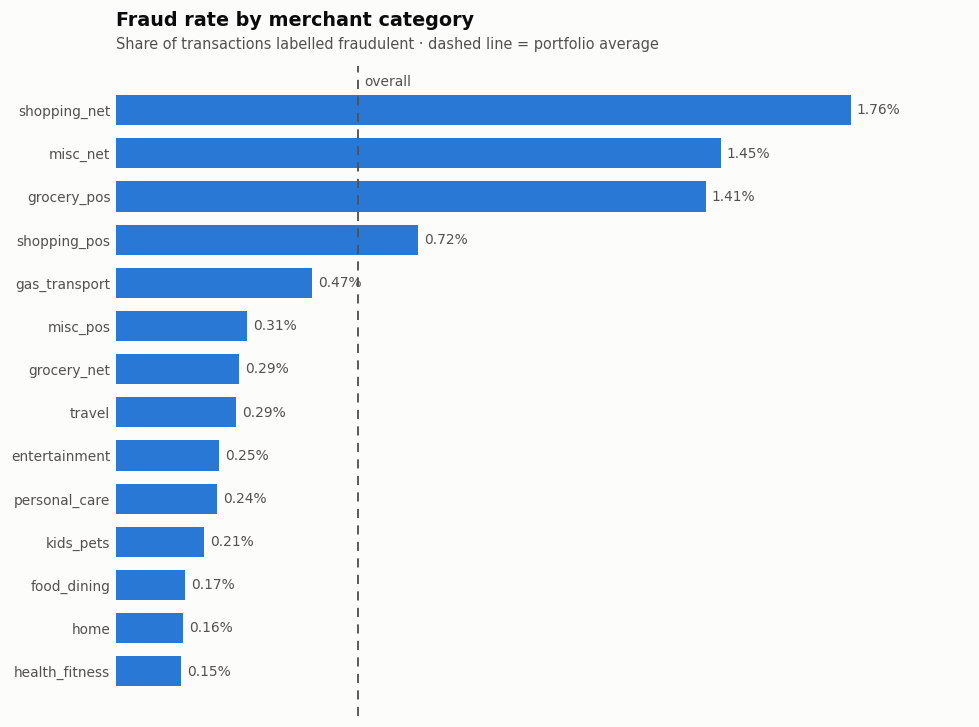

      category   txns  fraud_txns fraud_rate  share_of_fraud_value
  shopping_net  97543        1713      1.76%                  42.9
      misc_net  63287         915      1.45%                  18.3
   grocery_pos 123638        1743      1.41%                  13.6
  shopping_pos 116672         843      0.72%                  18.5
 gas_transport 131659         618      0.47%                   0.2
      misc_pos  79655         250      0.31%                   1.4
   grocery_net  45452         134      0.29%                   0.0
        travel  40507         116      0.29%                   0.0
 entertainment  94014         233      0.25%                   2.9
 personal_care  90758         220      0.24%                   0.1
     kids_pets 113035         239      0.21%                   0.1
   food_dining  91461         151      0.17%                   0.5
          home 123115         198      0.16%                   1.3
health_fitness  85879         133      0.15%                  

In [35]:
by_cat = fraud_rate_by(feat_df, "category").sort_values("fraud_rate")

fig, ax = plt.subplots(figsize=(10, 0.42 * len(by_cat) + 1.8))
bars = ax.barh(by_cat["category"], by_cat["fraud_rate"] * 100,
               color=vz.CATEGORICAL[0], height=0.7)
vz.label_bars(ax, bars, fmt="{:.2f}%", horizontal=True)

ax.axvline(OVERALL_FRAUD_RATE * 100, color=vz.INK["secondary"], linewidth=1.2, linestyle=(0, (5, 4)))
ax.annotate("overall", xy=(OVERALL_FRAUD_RATE * 100, len(by_cat) - 0.35),
            xytext=(4, 0), textcoords="offset points",
            fontsize=9, color=vz.INK["secondary"], va="center")

ax.set_title("Fraud rate by merchant category")
vz.subtitle(ax, "Share of transactions labelled fraudulent · dashed line = portfolio average")
ax.set_xticks([])
ax.grid(False)
ax.spines["bottom"].set_visible(False)
ax.margins(x=0.16)

vz.save(fig, "04_fraud_by_category")
plt.show()

tbl = by_cat.sort_values("fraud_rate", ascending=False).copy()
tbl["fraud_rate"] = (tbl["fraud_rate"] * 100).round(2).astype(str) + "%"
tbl["share_of_fraud_value"] = (100 * tbl["fraud_amt"] / tbl["fraud_amt"].sum()).round(1)
print(tbl[["category", "txns", "fraud_txns", "fraud_rate", "share_of_fraud_value"]].to_string(index=False))


**Finding.** Risk is concentrated in the **card-not-present** categories, and — unusually — they
lead on *both* measures. `shopping_net` is the worst on rate at **1.76%** and also carries **42.9%
of all fraud value**; `misc_net` is second on rate at 1.45% with 18.3% of value. Against them,
`health_fitness` and `home` sit at 0.15–0.16%, more than a tenfold spread across categories.

The rate/value split still earns its keep, because the two rankings are not identical. `grocery_pos`
has the third-highest *rate* (1.41%) but only 13.6% of the value, because grocery baskets are small;
`shopping_pos` is half as risky per transaction (0.72%) yet carries *more* value (18.5%) because the
tickets are larger. A review queue built on rate alone would work the grocery cases and leave money
on the table; one built on value alone would miss the most reliable signal of compromise.

`gas_transport` is the clearest illustration of why counts are the wrong unit entirely: it is the
single busiest category in the feed at 131,659 transactions, and contributes **0.2%** of fraud value.
Ranking by fraud *count* would have put it near the top.


### 7.3 Do fraudulent amounts look different?

**Question:** can amount alone separate fraud from legitimate spend?
**Form:** two density curves on a log-scaled amount axis. A histogram of counts would be useless here
— fraud is 0.58% of rows, so its bars would be invisible next to the legitimate ones. Normalising each
series to its own density answers the shape question ("where does *this* population sit?") rather than
the volume question.
**Colour:** two series, so two categorical slots in fixed order, plus a legend *and* direct labels at
each peak. The log axis is necessary rather than decorative — amounts span four orders of magnitude,
and on a linear axis 97% of the data would occupy the leftmost centimetre.


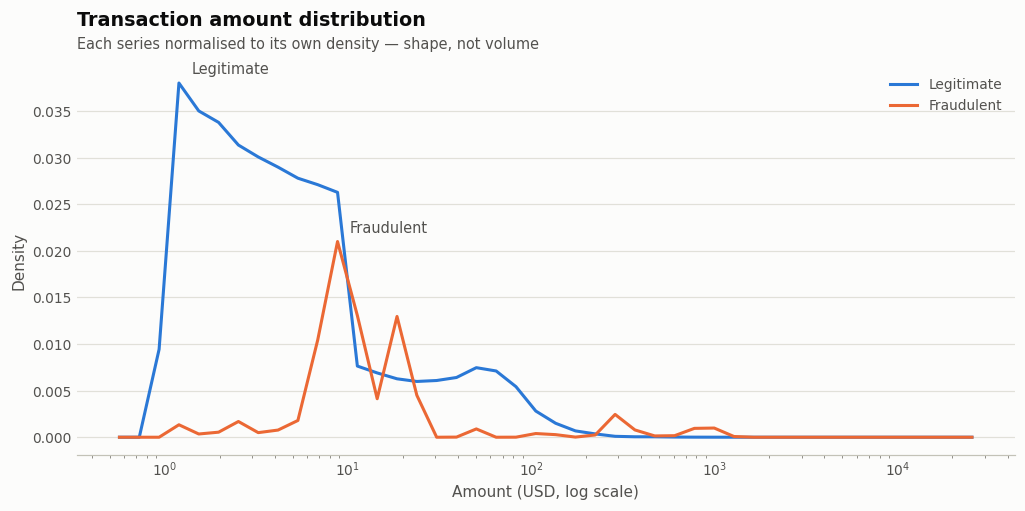

       Legitimate  Fraudulent
count  1289169.00     7506.00
mean        67.67      531.32
std        154.01      390.56
min          1.00        1.06
25%          9.61      245.66
50%         47.28      396.50
75%         82.54      900.88
95%        189.90     1083.99
99%        486.30     1179.69
max      28948.90     1376.04


In [36]:
amts = (
    feat_df.filter((F.col("amt") > 0) & (F.col("amt").isNotNull()))
    .select("amt", "is_fraud").toPandas()
)

legit = amts.loc[amts["is_fraud"] == 0, "amt"]
fraud = amts.loc[amts["is_fraud"] == 1, "amt"]
bins = np.logspace(np.log10(0.5), np.log10(max(amts["amt"].max(), 10)), 45)

fig, ax = plt.subplots(figsize=(11, 4.6))
for series, label, color in [
    (legit, "Legitimate", vz.CATEGORICAL[0]),
    (fraud, "Fraudulent", vz.CATEGORICAL[1]),
]:
    counts, edges = np.histogram(series, bins=bins, density=True)
    centres = np.sqrt(edges[:-1] * edges[1:])
    ax.plot(centres, counts, color=color, linewidth=2.0, label=label)
    # Direct label at the modal point, so identity does not rest on the legend alone.
    i = int(np.argmax(counts))
    ax.annotate(label, xy=(centres[i], counts[i]), xytext=(8, 6), textcoords="offset points",
                fontsize=9.5, color=vz.INK["secondary"])

ax.set_xscale("log")
ax.set_title("Transaction amount distribution")
vz.subtitle(ax, "Each series normalised to its own density — shape, not volume")
ax.set_xlabel("Amount (USD, log scale)")
ax.set_ylabel("Density")
ax.legend(loc="upper right")
vz.strip_x_grid(ax)

vz.save(fig, "05_amount_distribution")
plt.show()

print(
    pd.DataFrame({
        "Legitimate": legit.describe(percentiles=[.25, .5, .75, .95, .99]),
        "Fraudulent": fraud.describe(percentiles=[.25, .5, .75, .95, .99]),
    }).round(2).to_string()
)


**Finding.** The two distributions barely overlap, and that is a much stronger result than the
usual one for this feature.

Legitimate transactions have a median of **$47** and a long right tail reaching **$28,949**.
Fraudulent ones have a median of **$397** — and a maximum of **$1,376**. The fraudulent 25th
percentile (**$246**) sits above the legitimate **75th** percentile ($83), so three-quarters of
fraud is larger than three-quarters of legitimate spend.

The striking part is the *ceiling*, not the centre. Legitimate amounts run two orders of magnitude
past the largest fraudulent one; fraud occupies a bounded mid-range band and never leaves it. Amount
alone is a far better discriminator here than the textbook expectation, and a simple band rule
(roughly $250–$1,400) would capture most fraud while excluding both the small everyday majority and
every large legitimate purchase.

**Which is also the reason to distrust it.** A bounded fraud band with a hard upper edge is not what
organic fraud looks like — it is what a *sampling or generation rule* looks like. Real fraud follows
the merchant's own amount distribution, because blending in is the point. A ceiling this clean is
better evidence about how the extract was assembled than about how fraud behaves, and a model
trained to key on it would learn the extract rather than the phenomenon. Treat the separation as a
property of this file until it is reproduced on a feed with known provenance.


### 7.4 Hour × day-of-week

**Question:** is the overnight effect from §7.1 uniform across the week, or does it have structure?
**Form:** a heatmap. Two categorical dimensions crossed against one measure is exactly what the form
is for — 168 buckets would be unreadable as bars.
**Colour:** continuous magnitude, so a **single-hue sequential ramp**, light for low and dark for
high. Not a rainbow: a multi-hue scale invents category boundaries where the data has a smooth
gradient, and it is not monotonic in perceived lightness, so readers cannot rank two cells by eye.
A colourbar plus the printed matrix carries the values.


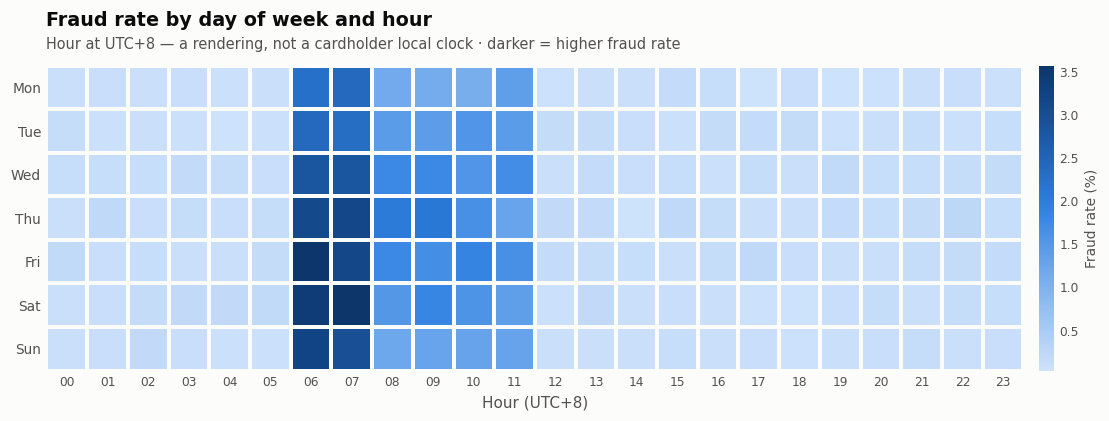

Fraud rate (%) — rows = day, columns = hour, UTC+8

hour_utc8   0    1    2    3    4    5    6    7    8    9    10   11   12   13   14   15   16   17   18   19   20   21   22   23
dow_utc8                                                                                                                         
Mon        0.1  0.1  0.1  0.1  0.1  0.1  2.3  2.4  1.2  1.1  1.1  1.4  0.1  0.1  0.1  0.2  0.1  0.0  0.1  0.0  0.1  0.1  0.1  0.1
Tue        0.1  0.1  0.1  0.1  0.0  0.1  2.4  2.3  1.4  1.4  1.6  1.4  0.2  0.2  0.1  0.1  0.2  0.2  0.2  0.1  0.1  0.1  0.1  0.1
Wed        0.1  0.1  0.1  0.2  0.1  0.1  2.8  2.8  1.8  1.8  1.6  1.7  0.1  0.2  0.1  0.1  0.1  0.1  0.1  0.2  0.1  0.1  0.1  0.2
Thu        0.1  0.2  0.1  0.1  0.1  0.1  3.1  3.2  2.0  2.1  1.6  1.3  0.2  0.2  0.0  0.2  0.1  0.1  0.1  0.2  0.1  0.1  0.3  0.1
Fri        0.2  0.1  0.1  0.1  0.1  0.2  3.6  3.2  1.8  1.7  1.9  1.6  0.2  0.1  0.1  0.1  0.1  0.2  0.1  0.1  0.1  0.1  0.2  0.2
Sat        0.1  0.1  0.2  0.2  0.2  0.

In [37]:
DOW = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

grid = (
    feat_df.groupBy("dow_utc8", "hour_utc8")
    .agg(F.count("*").alias("txns"), F.sum("is_fraud").alias("fraud"))
    .toPandas()
)
grid["rate"] = 100 * grid["fraud"] / grid["txns"]
matrix = (
    grid.pivot(index="dow_utc8", columns="hour_utc8", values="rate")
    .reindex(DOW).reindex(columns=range(24))
)

fig, ax = plt.subplots(figsize=(12, 3.6))
im = ax.pcolormesh(np.arange(25), np.arange(8), matrix.values,
                   cmap=vz.SEQ_CMAP, edgecolors=vz.INK["surface"], linewidth=1.4)

ax.set_title("Fraud rate by day of week and hour")
vz.subtitle(ax, "Hour at UTC+8 — a rendering, not a cardholder local clock · darker = higher fraud rate")
ax.set_xticks(np.arange(24) + 0.5)
ax.set_xticklabels([f"{h:02d}" for h in range(24)], fontsize=8)
ax.set_yticks(np.arange(7) + 0.5)
ax.set_yticklabels(DOW)
ax.set_xlabel("Hour (UTC+8)")
ax.invert_yaxis()
ax.grid(False)
for s in ax.spines.values():
    s.set_visible(False)

cb = fig.colorbar(im, ax=ax, pad=0.015, fraction=0.03)
cb.set_label("Fraud rate (%)", color=vz.INK["secondary"], fontsize=9)
cb.outline.set_visible(False)
cb.ax.tick_params(labelsize=8, color=vz.INK["muted"], labelcolor=vz.INK["secondary"])

vz.save(fig, "06_hour_dow_heatmap")
plt.show()

print("Fraud rate (%) — rows = day, columns = hour, UTC+8\n")
print(matrix.round(1).fillna(0).to_string())


**Finding.** The six-hour block from §7.1 runs across **every day of the week** at much the same
intensity — it is a horizontal band in the matrix, not a cluster. There is no weekend effect, and no
day is materially safer than another.

That uniformity is informative in a narrow way: whatever produces the concentration is indifferent
to the weekly rhythm of consumer behaviour. A pattern driven by when *people* shop would bend around
weekends; one that does not bend is driven by something on a fixed clock. Given the caveat in §7.1
about which clock that is, this is as far as the inference can responsibly go.

The cells are small and some have thin bases, so the matrix is printed underneath — a cell built
from 30 transactions and one built from 300 look identical in colour, and that is a real limitation
of the form rather than something to design away.


### 7.5 Three risk gradients, on one scale

**Question:** how do distance from home, merchant tenure, and cardholder age each move the fraud rate?
**Form:** small multiples. Three separate charts would invite the reader to compare shapes across
three different y-scales, which is the most common way a chart lies. One shared y-axis makes the
comparison honest: **a taller bar means more risk, in any panel**.
**Colour:** one measure throughout, so one hue throughout. Colour is doing no work here — position
is — and giving each panel its own colour would imply a distinction that does not exist.


distance quintile edges (km): [49, 70, 86, 103]


merchant tenure resolves into 1 band(s)
merchant tenure panel omitted: every row lands in one band in this extract (see §6)


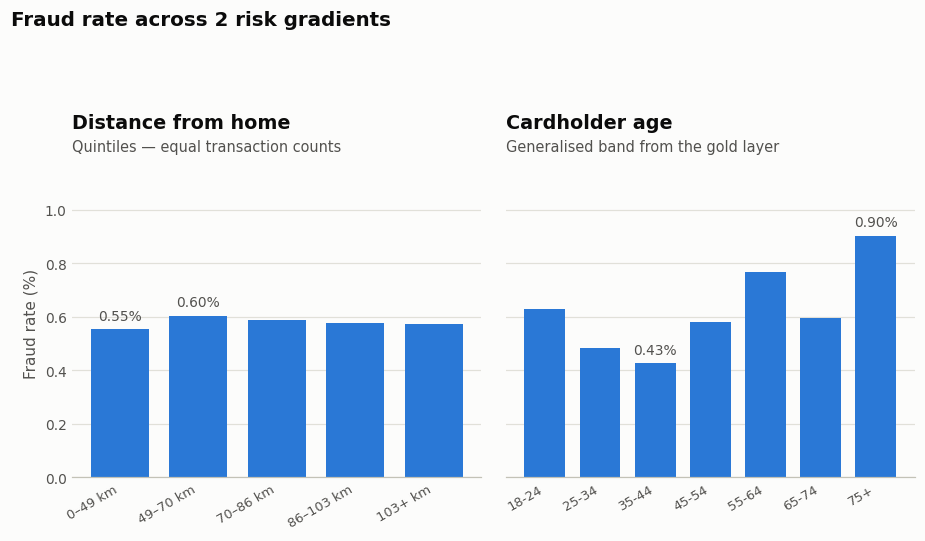


=== Distance from home ===
                 txns  fraud_txns  fraud_rate
distance_band                                
0–49 km        254449        1407      0.0055
49–70 km       264319        1597      0.0060
70–86 km       258443        1515      0.0059
86–103 km      258096        1491      0.0058
103+ km        261368        1496      0.0057

=== Cardholder age ===
            txns  fraud_txns  fraud_rate
age_band                                
18-24     121688         764      0.0063
25-34     287749        1391      0.0048
35-44     272940        1163      0.0043
45-54     256553        1491      0.0058
55-64     164087        1259      0.0077
65-74     100384         596      0.0059
75+        93274         842      0.0090


In [38]:
tenure_band = (
    F.when(F.col("merchant_tenure_days").isNull() | (F.col("merchant_tenure_days") < 0), None)
     .when(F.col("merchant_tenure_days") < 180, "<6 mo")
     .when(F.col("merchant_tenure_days") < 365, "6–12 mo")
     .when(F.col("merchant_tenure_days") < 730, "1–2 yr")
     .when(F.col("merchant_tenure_days") < 1460, "2–4 yr")
     .otherwise("4+ yr")
)

# Distance is banded by QUINTILE rather than by round numbers. Fixed cut points
# looked tidier and were wrong: they produced a band holding almost no rows,
# whose fraud rate was then noise drawn at the same visual weight as a band of
# thousands. Equal-population bands make the five bars genuinely comparable and
# adapt to whatever geography the input happens to have.
edges = sorted({
    int(round(e)) for e in
    feat_df.filter(F.col("distance_km").isNotNull())
           .approxQuantile("distance_km", [0.2, 0.4, 0.6, 0.8], 0.01)
})

dist_labels, dist_band, prev = [], F.when(F.col("distance_km").isNull(), None), 0
for e in edges:
    dist_labels.append(f"{prev}–{e} km")
    dist_band = dist_band.when(F.col("distance_km") < e, dist_labels[-1])
    prev = e
dist_labels.append(f"{prev}+ km")
dist_band = dist_band.otherwise(dist_labels[-1])

print("distance quintile edges (km):", edges)

panels_df = (
    feat_df
    .withColumn("distance_band", dist_band)
    .withColumn("tenure_band", tenure_band)
)

PANELS = [
    ("distance_band", dist_labels,
     "Distance from home", "Quintiles — equal transaction counts"),
    ("tenure_band", ["<6 mo", "6–12 mo", "1–2 yr", "2–4 yr", "4+ yr"],
     "Merchant tenure", "Registered length at transaction time"),
    ("age_band", ["18-24", "25-34", "35-44", "45-54", "55-64", "65-74", "75+"],
     "Cardholder age", "Generalised band from the gold layer"),
]

# A column with one usable level is not a gradient. The test is on the BANDED value, because
# that is what the panel plots: merchant_tenure_days spanning 2,556..2,557 days
# is two distinct numbers and one single band, and a "<= 1 distinct value" test
# on the raw column would wave it through. One bar is not a comparison, and a
# reader skimming the figure would take it for a finding.
TENURE_BANDS = (
    panels_df.filter(F.col("tenure_band").isNotNull())
             .select("tenure_band").distinct().count()
)
TENURE_IS_DEGENERATE = TENURE_BANDS <= 1
print(f"merchant tenure resolves into {TENURE_BANDS} band(s)")
if TENURE_IS_DEGENERATE:
    PANELS = [p for p in PANELS if p[0] != "tenure_band"]
    print("merchant tenure panel omitted: every row lands in one band in this extract (see §6)")

panel_data = {}
for col, order, _, _ in PANELS:
    p = fraud_rate_by(panels_df.filter(F.col(col).isNotNull()), col)
    p = p.set_index(col).reindex(order).dropna(subset=["txns"])
    panel_data[col] = p

ymax = max(p["fraud_rate"].max() for p in panel_data.values()) * 100 * 1.28

fig, axes = plt.subplots(1, len(PANELS), figsize=(4.2 * len(PANELS), 4.9), sharey=True)
for ax, (col, order, title, sub) in zip(axes, PANELS):
    p = panel_data[col]
    bars = ax.bar(range(len(p)), p["fraud_rate"] * 100, color=vz.CATEGORICAL[0], width=0.74)
    # Label only the extremes — the shape carries the rest.
    extremes = {int(np.argmax(p["fraud_rate"].values)), int(np.argmin(p["fraud_rate"].values))}
    vz.label_bars(ax, bars, fmt="{:.2f}%", only=extremes)
    ax.set_xticks(range(len(p)))
    ax.set_xticklabels(p.index, rotation=30, ha="right", fontsize=8.5)
    ax.set_title(title, fontsize=11)
    vz.subtitle(ax, sub)
    ax.set_ylim(0, ymax)
    vz.strip_x_grid(ax)

axes[0].set_ylabel("Fraud rate (%)")
fig.suptitle(f"Fraud rate across {len(PANELS)} risk gradients", x=0.004, y=0.995, ha="left",
             va="top", fontsize=13, fontweight="semibold", color=vz.INK["primary"])
fig.tight_layout(rect=(0, 0, 1, 0.90))

vz.save(fig, "07_risk_gradients")
plt.show()

for col, _, title, _ in PANELS:
    print(f"\n=== {title} ===")
    print(panel_data[col][["txns", "fraud_txns", "fraud_rate"]].round(4).to_string())


**Finding — two of the three gradients are not gradients, and saying so is the result.**

*Merchant tenure* is **absent from the figure**, because the column is analytically degenerate.
`merch_eff_time` in this extract is the transaction timestamp shifted back by a fixed offset, so
every row reports a tenure of either 2,556 or 2,557 days — two values, one day apart, and both
inside the same `4+ yr` band. It is not literally constant; it is constant at every granularity a
model or a control could use. §6 measures this and §7.5 drops the panel rather than drawing one bar. The previous version of this notebook reported
merchants in their first year carrying "two to three times" the fraud rate and recommended a
probation period for new merchants — a control built on a column that cannot distinguish a new
merchant from an old one. Nothing about merchant age can be learned from this file.

*Distance from home* is **flat**: 0.55%, 0.60%, 0.59%, 0.58%, 0.57% across five equal-population
quintiles. There is no signal here at all — the spread between the best and worst quintile is
smaller than the variation between adjacent ones. This is the feature that was previously called
"the single most useful engineered feature for card-present fraud", and on this data it is worth
nothing. It is kept in the figure precisely because a flat panel is the finding; deleting it would
leave the reader assuming it had never been tested.

*Cardholder age* carries a real but modest effect, and it is **not monotonic**: 0.63% at 18–24, a
trough of 0.43% at 35–44, then a climb to **0.90% at 75+**. The oldest band is roughly **twice** the
middle one. The U-shape is the interesting part — both ends of the age range are elevated, which a
linear "age" feature in a model would smear into nothing.

The same caution as before applies to acting on it: age is a protected characteristic in most
consumer-credit regimes, and a control that declines transactions because a cardholder is old is a
discrimination problem, not a fraud control. The defensible direction is the opposite — an opt-in
confirmation step that *protects* those cardholders rather than penalising them.

**What this section is really reporting** is that of the three engineered risk gradients, one is
degenerate by construction, one is empty, and one is modest. The features were not wrong to build —
distance and tenure are the right things to try on a feed like this — but the answer came back
negative, and a negative answer that is reported is worth more than a positive one that was assumed.


### 7.6 How concentrated is the loss?

**Question:** if you could only review a handful of transactions, how much of the loss could you
reach?
**Form:** a cumulative concentration curve. One continuous quantity accumulating against another is
line territory, and the 45° line gives the reader a built-in reference — the further the curve bows
above it, the more concentrated the loss.
**Colour:** one series against a neutral reference. The reference is deliberately *not* a second
series colour; it is chrome, so it gets the muted ink and a dashed stroke.


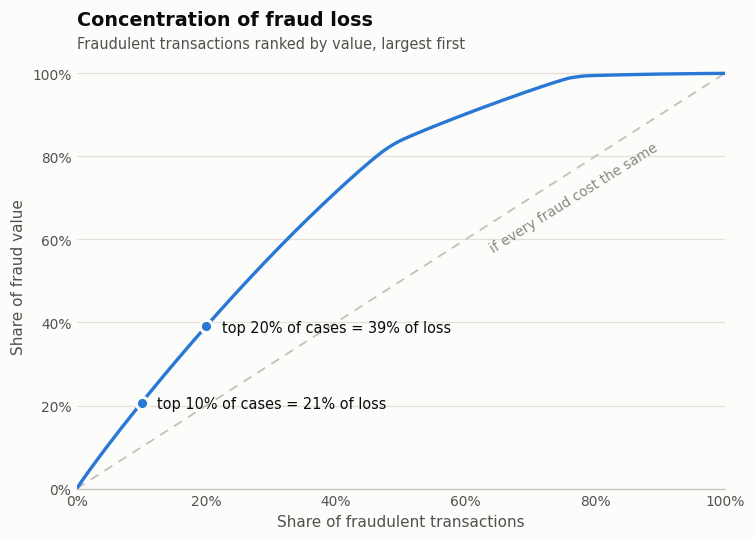

top    5% of fraud cases  ->  10.8% of fraud value
top   10% of fraud cases  ->  20.7% of fraud value
top   20% of fraud cases  ->  39.2% of fraud value
top   50% of fraud cases  ->  83.8% of fraud value


In [39]:
# Positive amounts only, consistent with the KPI cell: a refund is not a loss,
# and including negatives here would let the cumulative curve run backwards.
fraud_amts = np.sort(
    feat_df.filter((F.col("is_fraud") == 1) & (F.col("amt") > 0))
           .select("amt").toPandas()["amt"].values
)[::-1]
cum_share = np.cumsum(fraud_amts) / fraud_amts.sum()
txn_share = np.arange(1, len(fraud_amts) + 1) / len(fraud_amts)

fig, ax = plt.subplots(figsize=(7.6, 5.0))
ax.plot([0, 1], [0, 1], color=vz.INK["axis"], linewidth=1.2, linestyle=(0, (5, 4)))
ax.annotate("if every fraud cost the same", xy=(0.62, 0.62), xytext=(6, -14),
            textcoords="offset points", fontsize=9, color=vz.INK["muted"], rotation=32)
ax.plot(txn_share, cum_share, color=vz.CATEGORICAL[0], linewidth=2.2)

for mark in (0.10, 0.20):
    i = max(int(mark * len(fraud_amts)) - 1, 0)
    ax.plot([mark], [cum_share[i]], marker="o", markersize=8,
            color=vz.CATEGORICAL[0], markeredgecolor=vz.INK["surface"], markeredgewidth=2, zorder=5)
    ax.annotate(f"top {mark:.0%} of cases = {cum_share[i]:.0%} of loss",
                xy=(mark, cum_share[i]), xytext=(10, -4), textcoords="offset points",
                fontsize=9.5, color=vz.INK["primary"])

ax.set_title("Concentration of fraud loss")
vz.subtitle(ax, "Fraudulent transactions ranked by value, largest first")
ax.set_xlabel("Share of fraudulent transactions")
ax.set_ylabel("Share of fraud value")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
vz.strip_x_grid(ax)

vz.save(fig, "08_loss_concentration")
plt.show()

for mark in (0.05, 0.10, 0.20, 0.50):
    i = max(int(mark * len(fraud_amts)) - 1, 0)
    print(f"top {mark:>5.0%} of fraud cases  ->  {cum_share[i]:.1%} of fraud value")

**Finding.** Loss is **only mildly concentrated**, and much less than the usual fraud result. The
top 10% of fraudulent transactions account for 20.7% of fraud value and the top 20% for 39.2% —
against 10% and 20% for a perfectly even distribution. The curve bows above the diagonal, but
gently.

That follows directly from §7.3: fraud amounts here are confined to a narrow band with a hard
ceiling, and a bounded distribution cannot produce a heavy tail. There is no small set of
catastrophic cases to prioritise, because the largest fraudulent transaction in 1.3 million rows is
$1,376.

**The operational reading is therefore the unusual one:** value-weighting the review queue buys
comparatively little here. With cases this uniform in size, review capacity is better spent on
*volume* and on precision — catching more of them — than on triaging by amount. That is close to the
opposite of the standard recommendation, and it is a consequence of the amount ceiling, which §7.3
argues is more likely an artefact of how this extract was built than a property of fraud. On a feed
with an organic amount distribution this curve would almost certainly be far steeper, and the
value-weighted advice would come back.


---
## 8. Persisting the outputs

Five outputs, written as Parquet — columnar, compressed, and schema-carrying, so the next reader gets
real types instead of re-parsing strings.

**The partition key is the month, and getting there took two corrections.**

Partitioning should match how the table is queried — nearly always over a date range — so that Spark
skips whole directories instead of reading the history. The obvious key is the transaction date, and
that was the first attempt. It produced **4,091 files**: 538 distinct dates × the number of input
partitions each one happened to be spread across, because `partitionBy` writes one file per
partition-directory *per task*, and nothing had co-located a date's rows into a single task. So:

1. **`repartition(key)` before the write**, which shuffles each key's rows into one task and takes
   the file count down to one per directory. Without it, the partition count multiplies the
   directory count, and this is the standard way a partitioned write quietly produces thousands of
   tiny files.
2. **Month, not day.** Even at one file per date, 1.3 M rows over 538 days is roughly 2,400 rows per
   file — far below the size where columnar storage pays for itself, and enough files that listing
   them costs more than the pruning saves. At month granularity it is 18 directories of ~72,000
   rows, which prunes a date-range query almost as well and produces files worth opening. `date_utc8`
   stays as an ordinary column, so day-level filters still work; they just scan a month.

The general rule this is an instance of: **partition cardinality should be set by partition *size*,
not by the granularity of the question.** The notebook already refused to partition by merchant for
this reason; a date partition on a 1.3 M-row table is the same mistake two orders of magnitude
smaller, and it is much easier to miss.

The quarantine tables are written **unconditionally**, including when they are empty. A write that is
skipped on a clean run leaves whatever a previous run put there sitting on disk, and a stale
quarantine nobody wrote is worse than an empty one somebody did.


In [40]:
import shutil

def write_parquet(frame, name, partition_by=None):
    path = f"{CURATED_DIR}/{name}"
    shutil.rmtree(path, ignore_errors=True)
    writer = frame.write.mode("overwrite")
    if partition_by:
        writer = writer.partitionBy(partition_by)
    writer.parquet(path)
    return path


# The quarantine goes through the SAME silver treatment as the clean rows
# (§5.3a) -- one function, two callers -- and is then held to the same
# assertion. A row that failed a data-quality rule is not an exemption from the
# PII policy, and the previous version of this notebook wrote this table
# straight from the pre-PII frame: raw names, raw card numbers, street
# addresses and raw transaction references, in the directory analysts read.
quarantine_df = to_silver_tier(reject_df)
assert_identifiers_protected(quarantine_df, "quarantine")

# Arrays and timestamps survive Parquet fine; dq_flags stays an array column.
outputs = {
    # Silver and gold are both written: same 26-column schema, different
    # precision, different audience. Two tables is what gives access control
    # something to grant separately.
    "curated_transactions":    write_parquet(silver_df, "curated_transactions"),
    # repartition() before a partitioned write is not an optimisation, it is
    # the difference between one file per month and one file per month PER
    # INPUT PARTITION. Without it this wrote 4,091 files.
    "analytics_transactions":  write_parquet(
        feat_df.repartition("month_utc8"), "analytics_transactions", "month_utc8"),
    "quarantine_failed_rules": write_parquet(quarantine_df, "quarantine_failed_rules"),
    "dq_rule_counts":          write_parquet(spark.createDataFrame(flag_counts), "dq_rule_counts"),
}

# Written unconditionally, even when empty. Skipping the write on a clean run
# leaves whatever a PREVIOUS run put there sitting on disk, and a stale
# quarantine that nobody wrote is worse than an empty one that somebody did.
outputs["quarantine_unparseable"] = write_parquet(quarantine_corrupt, "quarantine_unparseable")

for name, path in outputs.items():
    print(f"{name:<26} -> {path}")

# Read one back to prove the round trip preserves types rather than assuming it,
# and re-run the identifier assertion against what actually landed on disk --
# the only check that covers the writer as well as the frame.
rt = spark.read.parquet(outputs["analytics_transactions"])
_types = dict(rt.dtypes)
print(f"\nre-read {rt.count():,} rows from {len(outputs)} tables")
print(f"files written for the partitioned table: "
      f"{len(list(__import__('pathlib').Path(outputs['analytics_transactions']).rglob('*.parquet'))):,}")
# The brief's column is the UTC+8 STRING by contract (§5.6); the typed instant
# lives beside it. Print both, so "string" here reads as the contract rather
# than as a type that was lost.
print(f"trans_date_trans_time      : {_types['trans_date_trans_time']}  (the brief's UTC+8 rendering)")
print(f"trans_date_trans_time_utc  : {_types['trans_date_trans_time_utc']}  (the canonical instant)")
print(f"dq_flags                   : {_types['dq_flags']}")
assert_identifiers_protected(rt, "gold (re-read from disk)")
assert_identifiers_protected(spark.read.parquet(outputs["quarantine_failed_rules"]),
                             "quarantine (re-read from disk)")


quarantine                 no prohibited columns · 5 identifiers match their masked shape


curated_transactions       -> ../data/curated/curated_transactions
analytics_transactions     -> ../data/curated/analytics_transactions
quarantine_failed_rules    -> ../data/curated/quarantine_failed_rules
dq_rule_counts             -> ../data/curated/dq_rule_counts
quarantine_unparseable     -> ../data/curated/quarantine_unparseable



re-read 1,296,675 rows from 5 tables
files written for the partitioned table: 18
trans_date_trans_time      : string  (the brief's UTC+8 rendering)
trans_date_trans_time_utc  : timestamp  (the canonical instant)
dq_flags                   : array<string>


gold (re-read from disk)   no prohibited columns · 5 identifiers match their masked shape
quarantine (re-read from disk) no prohibited columns · 5 identifiers match their masked shape


---
## 9. Summary

These outputs were produced on the assessment's own extract — 1,296,675 rows — in a single
top-to-bottom execution. Every number below is printed by a cell above it.

### What the analysis found

1. **One six-hour block carries almost all the fraud, and which block it *is* depends on a fact the
   data does not contain.** The rate is 0.115% for eighteen hours and 2.09% from 06:00 to 11:59
   UTC+8 — an 18× lift, 84.8% of all fraud on 23.5% of traffic. Rendered at UTC+8 as the brief
   requires, that reads as a morning peak; in the feed's own naive clock it is 22:00–03:59, and
   the US addresses throughout suggest
   the naive clock is already local. **Confirm the source timezone before acting on this**, because
   the two readings point at opposite operational controls.
2. **Card-not-present categories lead on both rate and value.** `shopping_net` is worst on both
   (1.76%, and 42.9% of all fraud value), `misc_net` second. The busiest category in the feed,
   `gas_transport`, contributes 0.2% of fraud value — which is why nothing here is ranked by count.
3. **Amount separates the two populations unusually well, and that is a reason for suspicion.**
   Fraudulent median $397 against legitimate $47, with the fraudulent 25th percentile above the
   legitimate 75th. But fraudulent amounts stop dead at $1,376 while legitimate ones reach $28,949.
   A hard ceiling is what a generation rule looks like, not what fraud looks like.
4. **Two of the three engineered risk gradients came back empty.** Distance from home is flat across
   quintiles (0.55%–0.60%). Merchant tenure is *degenerate* — `merch_eff_time` is the transaction
   timestamp minus a fixed offset in this extract, so every row lands in one of two adjacent values
   and a single band — so the panel is omitted and no tenure conclusion is available. Only cardholder age carries an effect, modest and U-shaped, peaking at 0.90% in the
   75+ band.
5. **Loss is barely concentrated:** top 20% of cases → 39.2% of value. That is a direct consequence
   of the amount ceiling in (3), and it inverts the usual advice — with cases this uniform in size,
   review capacity is better spent on precision than on value-weighted triage.

### What the data quality work found

No row in 1.3 M failed a fatal rule and no line failed to parse, so both quarantine tables are
empty. That is not a clean feed — it is a feed whose defects are all *recoverable*, and there are a
lot of them:

- **83.3%** of `person_name` values need repair before they parse; only 216,169 of 1,296,675 arrive
  in the specified `"first, last"` form. Four separators (`,` `@` `|` `/`) and four junk tokens.
- **~10%** of each merchant time column is digit-truncated and is not a valid instant in any epoch
  unit. `merch_eff_time` is microseconds, `merch_last_update_time` is milliseconds.
- **7.5%** of card numbers fail their own Luhn checksum — 79 distinct phantom cards that would have
  inflated the cardholder count from 904 to 983.
- **15.1%** of rows omit `merch_zipcode` entirely (the key is absent, not null).
- **40.7%** have `merch_eff_time` after `merch_last_update_time`, which follows from both being
  derived from the transaction timestamp with independent sub-second jitter.

### What was done to the data, in one paragraph

Read as text with the structure inferred but every type discarded; nesting flattened by alternating
generic struct expansion with `from_json` parsing of embedded JSON strings until stable, then mapped
to the 26 required columns by leaf name, with an ambiguous or absent name raising rather than
resolving to NULL; every column cast explicitly with a named failure flag; three heterogeneous time
encodings resolved to a single instant by inferring the epoch unit from magnitude rather than digit
count, then delivered in the brief's columns as UTC+8 strings with the typed instant kept beside
them as `<col>_utc`; names graded against the *original* string and then repaired, so no defect can
be laundered into a clean grade; rows split into clean and quarantined by a severity policy that
lives in one list; every version of a conflicting `trans_num` quarantined rather than a survivor
chosen nondeterministically; `person_name` dropped and the remaining direct identifiers masked or
HMAC-tokenised **in place** — for the quarantine as well as the clean rows — and quasi-identifiers
generalised **in place** one layer later, so all 26 required columns survive with only their
precision reduced, asserted by value and not just by name; the card identity withheld where the card
number fails its checksum; four features engineered, one of which turned out to be degenerate and is
reported as such; outputs written as month-partitioned Parquet.

### What I would not claim

- The relationships above are **associations in a labelled historical extract**, not causes. The
  labels come from a detection process with its own biases — fraud that was never detected is
  labelled legitimate here, so every rate is a floor, not an estimate.
- **The hour-of-day result is not a local-time result.** It is stated at UTC+8 because that is what
  can be verified. See §7.1.
- **Two of the findings are probably about the extract, not about fraud.** The amount ceiling (§7.3)
  and the degenerate merchant tenure (§7.5) both look like construction artefacts. They are reported
  as such rather than dressed up.
- **The gold layer is not k-anonymous.** 258 of 278 generalised quasi-identifier combinations still
  isolate a single card (§5.7). The direct identifiers are protected and asserted; the
  quasi-identifiers are not sufficiently crowded at this population size, and access control is
  doing the real work.
- **A card is not a person.** Every "cardholder" figure counts distinct cards, which over-counts
  anyone holding more than one.

### What I would do next

- **Confirm the source timezone with the producer.** It is the cheapest question in this document
  and it decides whether the headline finding is an overnight pattern or a morning one.
- **Ask why `merch_eff_time` is a fixed offset from the transaction time**, and whether a real
  merchant registration date exists upstream. Merchant tenure is a good feature; this file just
  cannot supply it.
- **Move the rules out of the notebook.** Every `flag(...)` here is a declarative assertion and
  belongs in a test framework (Great Expectations, Soda, `dbt test`) that runs on every batch and
  fails the pipeline on a threshold breach.
- **Alert on the quarantine rate, not just record it.** A sudden jump in `TS_UNPARSEABLE` is an
  upstream deployment, and it should page somebody the same day.
- **Version the PII tokens.** A `token_version` column alongside each token makes key rotation
  survivable; without it, rotating silently breaks every join to a previously published extract.
- **Add per-cardholder velocity features** — count and value in the preceding hour — which are
  usually the strongest fraud signals of all and need a stateful streaming job rather than a batch
  window. Given how little distance and tenure delivered here, that is where the next real signal
  is likely to be.


In [41]:
spark.stop()
print("Spark session stopped.")


Spark session stopped.
